# Step 3: Data Preprocessing, Applied EDA, and Feature Engineering

This notebook prepares the eCommerce event dataset for leakage-safe future-purchase prediction.

The scope of this step includes:

1. Data cleaning  
2. Applied exploratory data analysis  
3. Leakage-safe feature engineering  
4. Correlation analysis  
5. PCA-based dimensionality reduction for exploratory analysis  
6. Embedded feature selection  
7. Saving the model-ready dataset 

# Import Libraries and Configure Project Paths

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd

from IPython.display import display

RANDOM_STATE = 42

current_folder = Path.cwd().resolve()

possible_project_roots = [
    current_folder,
    current_folder.parent
]

PROJECT_ROOT = next(
    (
        folder
        for folder in possible_project_roots
        if (folder / "data" / "raw" / "2020-Apr.csv").exists()
    ),
    None
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate project root. Expected file was not found:\n"
        "data/raw/2020-Apr.csv\n\n"
        "Please confirm that this notebook is inside project_folder/notebooks/"
        " or project_folder/."
    )

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "2020-Apr.csv"
PROCESSED_DATA_FOLDER = PROJECT_ROOT / "data" / "processed"
REPORTS_FOLDER = PROJECT_ROOT / "reports"

PROCESSED_DATA_FOLDER.mkdir(parents=True, exist_ok=True)
REPORTS_FOLDER.mkdir(parents=True, exist_ok=True)

SESSION_SAMPLE_PATH = (
    PROCESSED_DATA_FOLDER
    / "event_sample_session_preserved_approx_1m.csv"
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw dataset: {RAW_DATA_PATH}")
print(f"Processed-data folder: {PROCESSED_DATA_FOLDER}")
print(f"Session-preserved sample path: {SESSION_SAMPLE_PATH}")

Project root: C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder
Raw dataset: C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\raw\2020-Apr.csv
Processed-data folder: C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed
Session-preserved sample path: C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\event_sample_session_preserved_approx_1m.csv


# Rebuild the Session-Preserved Working Sample from Raw Data

In [3]:
# Rebuild the sample.
REBUILD_SAMPLE = True

CHUNK_SIZE = 250_000

# With around 66.6M source records, selecting 1 of 67 stable hash buckets
# should create an approximately 1M-event sample.
HASH_MODULUS = 67
HASH_BUCKET = 0

required_columns = [
    "event_time",
    "event_type",
    "product_id",
    "category_id",
    "category_code",
    "brand",
    "price",
    "user_id",
    "user_session"
]

column_dtypes = {
    "event_time": "string",
    "event_type": "string",
    "product_id": "string",
    "category_id": "string",
    "category_code": "string",
    "brand": "string",
    "price": "float64",
    "user_id": "string",
    "user_session": "string"
}

if SESSION_SAMPLE_PATH.exists() and REBUILD_SAMPLE:
    SESSION_SAMPLE_PATH.unlink()
    print("Existing session-preserved sample was removed for a clean rebuild.")

if SESSION_SAMPLE_PATH.exists() and not REBUILD_SAMPLE:
    print("Existing session-preserved sample found. Reusing saved file:")
    print(SESSION_SAMPLE_PATH)

else:
    total_rows_scanned = 0
    sampled_rows_written = 0
    write_header = True

    for chunk_number, chunk in enumerate(
        pd.read_csv(
            RAW_DATA_PATH,
            usecols=required_columns,
            dtype=column_dtypes,
            chunksize=CHUNK_SIZE
        ),
        start=1
    ):
        total_rows_scanned += len(chunk)

        # Sessions with missing IDs cannot be used for session-level analysis.
        valid_session_mask = chunk["user_session"].notna()

        session_hash = pd.util.hash_pandas_object(
            chunk.loc[valid_session_mask, "user_session"],
            index=False
        )

        selected_session_indexes = session_hash.index[
            (session_hash % HASH_MODULUS) == HASH_BUCKET
        ]

        sampled_chunk = chunk.loc[selected_session_indexes]

        if not sampled_chunk.empty:
            sampled_chunk.to_csv(
                SESSION_SAMPLE_PATH,
                mode="w" if write_header else "a",
                header=write_header,
                index=False
            )

            sampled_rows_written += len(sampled_chunk)
            write_header = False

        if chunk_number % 20 == 0:
            print(
                f"Scanned {total_rows_scanned:,} rows | "
                f"Sampled {sampled_rows_written:,} rows..."
            )

    if sampled_rows_written == 0:
        raise ValueError(
            "No rows were sampled. Please check the dataset and sampling setup."
        )

    print("\nSession-preserved sample creation completed.")
    print(f"Total raw rows scanned: {total_rows_scanned:,}")
    print(f"Sampled event records saved: {sampled_rows_written:,}")
    print(f"Saved sample file: {SESSION_SAMPLE_PATH}")

Scanned 5,000,000 rows | Sampled 74,729 rows...
Scanned 10,000,000 rows | Sampled 148,951 rows...
Scanned 15,000,000 rows | Sampled 225,678 rows...
Scanned 20,000,000 rows | Sampled 298,637 rows...
Scanned 25,000,000 rows | Sampled 371,050 rows...
Scanned 30,000,000 rows | Sampled 444,726 rows...
Scanned 35,000,000 rows | Sampled 517,481 rows...
Scanned 40,000,000 rows | Sampled 593,682 rows...
Scanned 45,000,000 rows | Sampled 667,769 rows...
Scanned 50,000,000 rows | Sampled 739,369 rows...
Scanned 55,000,000 rows | Sampled 811,422 rows...
Scanned 60,000,000 rows | Sampled 883,508 rows...
Scanned 65,000,000 rows | Sampled 959,074 rows...

Session-preserved sample creation completed.
Total raw rows scanned: 66,589,268
Sampled event records saved: 982,585
Saved sample file: C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\event_sample_session_preserved_approx_1m.csv


## Session-Preserved Working Sample Rebuild

A session-preserved working sample was rebuilt from the full raw eCommerce dataset. The raw file contained 66,589,268 event records. Using a deterministic hash-based sampling method on `user_session`, 982,585 event records were retained.

This approach preserves complete customer sessions rather than sampling individual event rows. Preserving full sessions is necessary because the project predicts whether a customer session will result in a future purchase.

The rebuilt sample was saved as `event_sample_session_preserved_approx_1m.csv` in the `data/processed/` folder and will be used for cleaning, EDA, and feature engineering in Step 3.

# Load and Validate the Rebuilt Working Sample

In [4]:
event_sample = pd.read_csv(
    SESSION_SAMPLE_PATH,
    dtype=column_dtypes
)

event_sample["event_time"] = pd.to_datetime(
    event_sample["event_time"],
    errors="coerce",
    utc=True
)

sample_validation_summary = pd.DataFrame({
    "metric": [
        "Sample event records",
        "Sample columns",
        "Unique sessions",
        "Unique users",
        "Earliest event timestamp",
        "Latest event timestamp",
        "Missing user_session values",
        "Invalid event_time values",
        "Exact duplicate full rows",
        "Estimated sample memory usage (MB)"
    ],
    "value": [
        f"{len(event_sample):,}",
        event_sample.shape[1],
        f"{event_sample['user_session'].nunique(dropna=True):,}",
        f"{event_sample['user_id'].nunique(dropna=True):,}",
        str(event_sample["event_time"].min()),
        str(event_sample["event_time"].max()),
        f"{event_sample['user_session'].isna().sum():,}",
        f"{event_sample['event_time'].isna().sum():,}",
        f"{event_sample.duplicated().sum():,}",
        f"{event_sample.memory_usage(deep=True).sum() / (1024 ** 2):,.2f}"
    ]
})

print("Session-Preserved Working Sample Validation")
display(sample_validation_summary)

print("First 10 records:")
display(event_sample.head(10))

Session-Preserved Working Sample Validation


,metric,value
0,Sample event records,"982,585"
1,Sample columns,9
2,Unique sessions,"173,519"
3,Unique users,"164,932"
4,Earliest event timestamp,2020-04-01 00:00:53+00:00
5,Latest event timestamp,2020-04-30 23:59:51+00:00
6,Missing user_session values,0
7,Invalid event_time values,0
8,Exact duplicate full rows,"1,921"
9,Estimated sample memory usage (MB),162.89


First 10 records:


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-04-01 00:00:53+00:00,view,2401882,2232732100769874463,appliances.personal.massager,artel,75.39,514570699,f66a18c2-2921-4d02-b316-21ad6e287b71
1,2020-04-01 00:01:06+00:00,view,15400227,2232732107774362287,<NA>,intex,241.71,568026442,0eab3224-ac58-4de3-bcb9-5e0523adc960
2,2020-04-01 00:01:24+00:00,view,2401531,2232732100769874463,appliances.personal.massager,elikor,85.20,514570699,f66a18c2-2921-4d02-b316-21ad6e287b71
3,2020-04-01 00:02:03+00:00,view,100063069,2053013554658804075,electronics.audio.headphone,hp,1029.37,614146688,0a51c272-01ce-4017-975f-ce5777b2ca49
4,2020-04-01 00:02:13+00:00,view,100166379,2232732107774362287,<NA>,intex,209.90,568026442,0eab3224-ac58-4de3-bcb9-5e0523adc960
5,2020-04-01 00:02:19+00:00,view,2401531,2232732100769874463,appliances.personal.massager,elikor,85.20,514570699,f66a18c2-2921-4d02-b316-21ad6e287b71
6,2020-04-01 00:02:38+00:00,view,100166379,2232732107774362287,<NA>,intex,209.90,568026442,0eab3224-ac58-4de3-bcb9-5e0523adc960
7,2020-04-01 00:04:37+00:00,view,2600756,2232732101835227701,<NA>,darina,244.51,514570699,f66a18c2-2921-4d02-b316-21ad6e287b71
8,2020-04-01 00:05:21+00:00,view,2600756,2232732101835227701,<NA>,darina,244.51,514570699,f66a18c2-2921-4d02-b316-21ad6e287b71
9,2020-04-01 00:05:59+00:00,view,2601165,2232732101835227701,<NA>,<NA>,262.51,514570699,f66a18c2-2921-4d02-b316-21ad6e287b71


## 3a. Data Cleaning: Duplicate Assessment

The rebuilt session-preserved sample contains exact duplicate event rows. Before removing them, the duplicates are assessed to confirm whether deduplication changes the session-level target label.

This is important because the project predicts future purchase at the session level. Duplicate removal should not alter whether a session converted, but it may affect behavioral counts such as views, cart actions, and total events.

# Assess Exact Duplicate Records

In [5]:
duplicate_group_mask = event_sample.duplicated(keep=False)

duplicate_records = event_sample.loc[duplicate_group_mask].copy()
deduplicated_event_sample = event_sample.drop_duplicates().copy()

duplicate_summary = pd.DataFrame({
    "metric": [
        "Total event records before deduplication",
        "Exact duplicate rows removed",
        "Records belonging to duplicate groups",
        "Unique duplicate groups",
        "Sessions affected by duplicate groups",
        "Event records after deduplication",
        "Percentage of records removed"
    ],
    "value": [
        f"{len(event_sample):,}",
        f"{event_sample.duplicated().sum():,}",
        f"{len(duplicate_records):,}",
        f"{duplicate_records.drop_duplicates().shape[0]:,}",
        f"{duplicate_records['user_session'].nunique():,}",
        f"{len(deduplicated_event_sample):,}",
        f"{event_sample.duplicated().mean():.4%}"
    ]
})

print("Duplicate Summary")
display(duplicate_summary)

duplicates_by_event_type = (
    duplicate_records
    .groupby("event_type", dropna=False)
    .size()
    .reset_index(name="records_in_duplicate_groups")
    .sort_values("records_in_duplicate_groups", ascending=False)
    .reset_index(drop=True)
)

duplicates_by_event_type["percentage_of_duplicate_group_records"] = (
    duplicates_by_event_type["records_in_duplicate_groups"]
    / len(duplicate_records)
    * 100
)

print("Duplicate-Group Records by Event Type")
display(duplicates_by_event_type)

Duplicate Summary


,metric,value
0,Total event records before deduplication,"982,585"
1,Exact duplicate rows removed,"1,921"
2,Records belonging to duplicate groups,"3,153"
3,Unique duplicate groups,"1,232"
4,Sessions affected by duplicate groups,932
5,Event records after deduplication,"980,664"
6,Percentage of records removed,0.1955%


Duplicate-Group Records by Event Type


,event_type,records_in_duplicate_groups,percentage_of_duplicate_group_records
0,cart,2568,81.446242
1,view,585,18.553758


### Duplicate Record Profile

The rebuilt working sample contained 1,921 exact duplicate event rows. These duplicate records were associated with 1,232 unique duplicate groups across 932 sessions. Removing the duplicates would reduce the dataset from 982,585 to 980,664 records, equivalent to only 0.1955% of the sample.

Duplicate records were concentrated in behavioral events. Cart events represented 81.45% of records belonging to duplicate groups, while view events represented 18.55%. Because duplicated cart and view actions could inflate session-level behavioral features, the effect of deduplication on session-level conversion labels was evaluated before applying the cleaning rule.

# Check Whether Deduplication Changes Session Labels

In [6]:
def create_session_target_for_cleaning(dataframe):
    """Create a complete-session conversion label for duplicate-impact assessment."""
    return (
        dataframe.assign(
            purchase_flag=dataframe["event_type"].eq("purchase").astype("int8")
        )
        .groupby("user_session", as_index=False)
        .agg(
            session_converted=("purchase_flag", "max"),
            event_count=("event_type", "size")
        )
    )


session_target_before = create_session_target_for_cleaning(event_sample)
session_target_after = create_session_target_for_cleaning(deduplicated_event_sample)

target_comparison = (
    session_target_before
    .merge(
        session_target_after,
        on="user_session",
        how="outer",
        suffixes=("_before", "_after"),
        validate="one_to_one"
    )
)

target_label_changes = target_comparison.loc[
    target_comparison["session_converted_before"]
    != target_comparison["session_converted_after"]
].copy()

session_event_count_changes = target_comparison.loc[
    target_comparison["event_count_before"]
    != target_comparison["event_count_after"]
].copy()

deduplication_impact_summary = pd.DataFrame({
    "metric": [
        "Sessions before deduplication",
        "Sessions after deduplication",
        "Sessions with changed conversion label",
        "Sessions with changed event count",
        "Maximum event-count reduction in one session"
    ],
    "value": [
        f"{len(session_target_before):,}",
        f"{len(session_target_after):,}",
        f"{len(target_label_changes):,}",
        f"{len(session_event_count_changes):,}",
        (
            f"{(session_event_count_changes['event_count_before'] - session_event_count_changes['event_count_after']).max():,}"
            if not session_event_count_changes.empty
            else "0"
        )
    ]
})

print("Impact of Deduplication on Session-Level Labels")
display(deduplication_impact_summary)

print("Example Duplicate Records")
display(
    duplicate_records
    .sort_values(["user_session", "event_time"])
    .head(15)
)

Impact of Deduplication on Session-Level Labels


,metric,value
0,Sessions before deduplication,"173,519"
1,Sessions after deduplication,"173,519"
2,Sessions with changed conversion label,0
3,Sessions with changed event count,932
4,Maximum event-count reduction in one session,36


Example Duplicate Records


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
680301,2020-04-23 07:48:27+00:00,cart,100013980,2232732093077520756,construction.tools.light,xiaomi,215.91,645834529,0003dda0-24a3-4779-85e8-d4030099714b
680302,2020-04-23 07:48:27+00:00,cart,100013980,2232732093077520756,construction.tools.light,xiaomi,215.91,645834529,0003dda0-24a3-4779-85e8-d4030099714b
680303,2020-04-23 07:48:27+00:00,cart,100013980,2232732093077520756,construction.tools.light,xiaomi,215.91,645834529,0003dda0-24a3-4779-85e8-d4030099714b
680304,2020-04-23 07:48:27+00:00,cart,100013980,2232732093077520756,construction.tools.light,xiaomi,215.91,645834529,0003dda0-24a3-4779-85e8-d4030099714b
622370,2020-04-21 15:28:06+00:00,cart,100011103,2053013554658804075,electronics.audio.headphone,acer,385.85,548745825,0046fbf5-e8aa-4ae9-b307-f5a7e153bf7b
622371,2020-04-21 15:28:06+00:00,cart,100011103,2053013554658804075,electronics.audio.headphone,acer,385.85,548745825,0046fbf5-e8aa-4ae9-b307-f5a7e153bf7b
474710,2020-04-17 14:48:42+00:00,cart,5100816,2232732103831716449,apparel.shoes,xiaomi,31.35,552427485,0047dc07-0638-4eef-8c8b-8e58a9cd3fe9
474711,2020-04-17 14:48:42+00:00,cart,5100816,2232732103831716449,apparel.shoes,xiaomi,31.35,552427485,0047dc07-0638-4eef-8c8b-8e58a9cd3fe9
864237,2020-04-28 02:59:35+00:00,cart,100082117,2232732079009824823,kids.skates,chicco,169.86,571783552,00cc1e3b-253f-48c6-848a-81c0f138081d
864238,2020-04-28 02:59:35+00:00,cart,100082117,2232732079009824823,kids.skates,chicco,169.86,571783552,00cc1e3b-253f-48c6-848a-81c0f138081d


### Deduplication Decision

Exact duplicate rows were removed from the working sample. The duplicate assessment confirmed that removing 1,921 duplicate rows did not change the number of sessions or any session-level conversion labels.

However, deduplication changed event counts for 932 sessions, with a maximum reduction of 36 events in one session. Because most duplicates were cart events, retaining them could inflate behavioral features such as cart count and total event count.

Therefore, exact duplicate records are removed before applied EDA and feature engineering.

# Apply Cleaning Rules

In [7]:
# Apply validated event-level cleaning rules.
cleaned_events = event_sample.drop_duplicates().copy()

# Standardize event type.
cleaned_events["event_type"] = (
    cleaned_events["event_type"]
    .astype("string")
    .str.strip()
    .str.lower()
)

# Standardize missing product descriptors.
cleaned_events["brand_clean"] = (
    cleaned_events["brand"]
    .astype("string")
    .str.strip()
    .replace("", pd.NA)
    .fillna("unknown")
    .str.lower()
)

cleaned_events["category_code_clean"] = (
    cleaned_events["category_code"]
    .astype("string")
    .str.strip()
    .replace("", pd.NA)
    .fillna("unknown")
    .str.lower()
)

# Ensure timestamp and price are correctly typed.
cleaned_events["event_time"] = pd.to_datetime(
    cleaned_events["event_time"],
    errors="coerce",
    utc=True
)

cleaned_events["price"] = pd.to_numeric(
    cleaned_events["price"],
    errors="coerce"
)

# Retain the original price, but use only positive prices for price-based features.
cleaned_events["price_for_aggregation"] = cleaned_events["price"].where(
    cleaned_events["price"].gt(0),
    np.nan
)

# Explicit data-quality flags.
cleaned_events["has_zero_price"] = cleaned_events["price"].eq(0).astype("int8")
cleaned_events["has_negative_price"] = cleaned_events["price"].lt(0).astype("int8")
cleaned_events["has_non_positive_price"] = cleaned_events["price"].le(0).astype("int8")

print("Cleaning rules applied.")
print(f"Cleaned event records: {len(cleaned_events):,}")

Cleaning rules applied.
Cleaned event records: 980,664


# Validate Cleaning, Missing Values, and Price Outliers

In [10]:
cleaning_audit = pd.DataFrame({
    "check": [
        "Event records after deduplication",
        "Unique sessions",
        "Exact duplicate rows remaining",
        "Missing user_session values",
        "Invalid event_time values",
        "Missing original brand values",
        "Missing original category_code values",
        "Unknown brand values after cleaning",
        "Unknown category_code values after cleaning",
        "Missing price values",
        "Zero-price event records retained",
        "Negative price records",
        "Non-positive price records",
        "Missing price_for_aggregation values"
    ],
    "value": [
        f"{len(cleaned_events):,}",
        f"{cleaned_events['user_session'].nunique(dropna=True):,}",
        f"{cleaned_events.duplicated().sum():,}",
        f"{cleaned_events['user_session'].isna().sum():,}",
        f"{cleaned_events['event_time'].isna().sum():,}",
        f"{cleaned_events['brand'].isna().sum():,}",
        f"{cleaned_events['category_code'].isna().sum():,}",
        f"{cleaned_events['brand_clean'].eq('unknown').sum():,}",
        f"{cleaned_events['category_code_clean'].eq('unknown').sum():,}",
        f"{cleaned_events['price'].isna().sum():,}",
        f"{cleaned_events['has_zero_price'].sum():,}",
        f"{cleaned_events['has_negative_price'].sum():,}",
        f"{cleaned_events['has_non_positive_price'].sum():,}",
        f"{cleaned_events['price_for_aggregation'].isna().sum():,}"
    ]
})

print("Cleaning Audit")
display(cleaning_audit)

price_percentiles = cleaned_events["price_for_aggregation"].quantile(
    [0.00, 0.01, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.00]
)

q1 = cleaned_events["price_for_aggregation"].quantile(0.25)
q3 = cleaned_events["price_for_aggregation"].quantile(0.75)
iqr = q3 - q1
iqr_upper_threshold = q3 + (1.5 * iqr)

price_outlier_summary = pd.DataFrame({
    "metric": [
        "Valid positive price records",
        "Minimum positive price",
        "1st percentile price",
        "25th percentile price",
        "Median price",
        "75th percentile price",
        "90th percentile price",
        "95th percentile price",
        "99th percentile price",
        "Maximum positive price",
        "IQR upper outlier threshold",
        "High-price outlier records",
        "High-price outlier percentage"
    ],
    "value": [
        f"{cleaned_events['price_for_aggregation'].notna().sum():,}",
        f"{price_percentiles.loc[0.00]:,.2f}",
        f"{price_percentiles.loc[0.01]:,.2f}",
        f"{price_percentiles.loc[0.25]:,.2f}",
        f"{price_percentiles.loc[0.50]:,.2f}",
        f"{price_percentiles.loc[0.75]:,.2f}",
        f"{price_percentiles.loc[0.90]:,.2f}",
        f"{price_percentiles.loc[0.95]:,.2f}",
        f"{price_percentiles.loc[0.99]:,.2f}",
        f"{price_percentiles.loc[1.00]:,.2f}",
        f"{iqr_upper_threshold:,.2f}",
        f"{cleaned_events['price_for_aggregation'].gt(iqr_upper_threshold).sum():,}",
        f"{cleaned_events['price_for_aggregation'].gt(iqr_upper_threshold).mean():.2%}"
    ]
})

print("Price Profile and Outlier Assessment")
display(price_outlier_summary)

assert cleaned_events.duplicated().sum() == 0
assert cleaned_events["user_session"].isna().sum() == 0
assert cleaned_events["event_time"].isna().sum() == 0
assert cleaned_events["has_negative_price"].sum() == 0

print("Critical cleaning validation checks passed.")

Cleaning Audit


,check,value
0,Event records after deduplication,"980,664"
1,Unique sessions,"173,519"
2,Exact duplicate rows remaining,0
3,Missing user_session values,0
4,Invalid event_time values,0
5,Missing original brand values,"132,514"
6,Missing original category_code values,"98,758"
7,Unknown brand values after cleaning,"132,514"
8,Unknown category_code values after cleaning,"98,758"
9,Missing price values,0


Price Profile and Outlier Assessment


,metric,value
0,Valid positive price records,"979,840"
1,Minimum positive price,0.14
2,1st percentile price,4.53
3,25th percentile price,51.48
4,Median price,149.04
5,75th percentile price,347.50
6,90th percentile price,704.27
7,95th percentile price,977.07
8,99th percentile price,"1,737.50"
9,Maximum positive price,"2,574.07"


Critical cleaning validation checks passed.


### Cleaning Validation and Price Outlier Decision

The cleaned event-level dataset contains 980,664 records across 173,519 unique sessions. All critical validation checks passed: no exact duplicate rows remain, no session identifiers are missing, no invalid timestamps were found, and no negative prices exist.

A total of 824 zero-price records were retained because they represent valid customer interactions. However, these zero values were converted to missing values in `price_for_aggregation` so that price-based features are calculated only from positive prices.

The positive-price distribution is right-skewed. The median price is 149.04, while the 99th percentile is 1,737.50 and the maximum price is 2,574.07. Based on the IQR rule, 81,447 records are flagged as high-price outliers. These records were retained because high prices can be valid in an eCommerce catalog with diverse product categories. Instead of removing them, later feature engineering and modeling steps will handle skewed price behavior through appropriate transformations, robust preprocessing, or model choice.

# Save Cleaned Event Dataset and Cleaning Audit

In [9]:
CLEANED_EVENTS_PATH = (
    PROCESSED_DATA_FOLDER
    / "event_sample_cleaned_for_eda_feature_engineering.csv"
)

CLEANING_AUDIT_PATH = (
    PROCESSED_DATA_FOLDER
    / "event_cleaning_audit.csv"
)

cleaned_events.to_csv(
    CLEANED_EVENTS_PATH,
    index=False
)

cleaning_audit.to_csv(
    CLEANING_AUDIT_PATH,
    index=False
)

print("Saved cleaned event-level dataset:")
print(CLEANED_EVENTS_PATH)

print("\nSaved cleaning audit:")
print(CLEANING_AUDIT_PATH)

Saved cleaned event-level dataset:
C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\event_sample_cleaned_for_eda_feature_engineering.csv

Saved cleaning audit:
C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\event_cleaning_audit.csv


## 3b. Applied EDA: Event and Session-Level Behavior

The cleaned event-level dataset is analyzed to understand customer behavior patterns before feature engineering. Since the project objective is to predict whether a customer session will lead to a future purchase, event-level data is aggregated into session-level summaries for exploratory analysis.

The EDA in this section uses complete-session information for descriptive purposes only. Predictive features will later be created using only the first two events of eligible sessions to prevent data leakage.

# Event Distribution and Session-Level EDA Dataset

In [11]:
# Reload cleaned events if the notebook is resumed from this point.
if "cleaned_events" not in globals():
    cleaned_events = pd.read_csv(
        PROCESSED_DATA_FOLDER
        / "event_sample_cleaned_for_eda_feature_engineering.csv"
    )

    cleaned_events["event_time"] = pd.to_datetime(
        cleaned_events["event_time"],
        errors="coerce",
        utc=True
    )

# Event-type distribution.
event_type_distribution = (
    cleaned_events
    .groupby("event_type", dropna=False)
    .size()
    .reset_index(name="event_count")
    .sort_values("event_count", ascending=False)
    .reset_index(drop=True)
)

event_type_distribution["event_percentage"] = (
    event_type_distribution["event_count"]
    / len(cleaned_events)
    * 100
)

print("Event-Type Distribution")
display(event_type_distribution)

# Create helper event flags.
eda_events = cleaned_events.copy()

eda_events["is_view"] = eda_events["event_type"].eq("view").astype("int8")
eda_events["is_cart"] = eda_events["event_type"].eq("cart").astype("int8")
eda_events["is_purchase"] = eda_events["event_type"].eq("purchase").astype("int8")

# Aggregate complete-session behavior for EDA only.
session_eda = (
    eda_events
    .groupby("user_session", as_index=False)
    .agg(
        user_id=("user_id", "first"),
        session_start=("event_time", "min"),
        session_end=("event_time", "max"),
        total_events=("event_type", "size"),
        view_count=("is_view", "sum"),
        cart_count=("is_cart", "sum"),
        purchase_count=("is_purchase", "sum"),
        unique_products=("product_id", "nunique"),
        unique_categories=("category_id", "nunique"),
        unique_brands=("brand_clean", "nunique"),
        zero_price_event_count=("has_zero_price", "sum"),
        average_positive_price=("price_for_aggregation", "mean"),
        median_positive_price=("price_for_aggregation", "median"),
        minimum_positive_price=("price_for_aggregation", "min"),
        maximum_positive_price=("price_for_aggregation", "max")
    )
)

session_eda["session_converted"] = (
    session_eda["purchase_count"].gt(0).astype("int8")
)

session_eda["session_duration_seconds"] = (
    session_eda["session_end"] - session_eda["session_start"]
).dt.total_seconds()

session_eda["session_duration_minutes"] = (
    session_eda["session_duration_seconds"] / 60
)

session_eda["has_cart_event"] = (
    session_eda["cart_count"].gt(0).astype("int8")
)

print(f"Session-level EDA dataset created: {len(session_eda):,} sessions")
display(session_eda.head(10))

Event-Type Distribution


,event_type,event_count,event_percentage
0,view,919621,93.775340
1,cart,46641,4.756063
2,purchase,14402,1.468597


Session-level EDA dataset created: 173,519 sessions


,user_session,user_id,session_start,session_end,total_events,view_count,cart_count,purchase_count,unique_products,unique_categories,unique_brands,zero_price_event_count,average_positive_price,median_positive_price,minimum_positive_price,maximum_positive_price,session_converted,session_duration_seconds,session_duration_minutes,has_cart_event
0,00003ede-f2e1-456b-bf72-6c95ab05b643,612466404,2020-04-19 12:36:42+00:00,2020-04-19 14:03:30+00:00,14,13,1,0,4,1,2,0,22.537143,21.340,20.57,33.21,0,5208.0,86.800000,1
1,0000a218-401c-48e0-81a8-50e6dc54d6be,642005903,2020-04-15 16:56:04+00:00,2020-04-15 16:56:23+00:00,2,2,0,0,2,1,1,0,259.710000,259.710,208.24,311.18,0,19.0,0.316667,0
2,0000a974-b2ba-4534-86ef-6c8736449a13,582705934,2020-04-08 04:22:56+00:00,2020-04-08 04:27:23+00:00,4,3,1,0,2,1,2,0,375.337500,408.480,275.91,408.48,0,267.0,4.450000,1
3,0003ce55-2131-4787-9d4f-821d28f77a4f,513012557,2020-04-11 15:39:03+00:00,2020-04-11 15:39:03+00:00,1,1,0,0,1,1,1,0,17.990000,17.990,17.99,17.99,0,0.0,0.000000,0
4,0003dda0-24a3-4779-85e8-d4030099714b,645834529,2020-04-23 07:22:31+00:00,2020-04-23 07:54:50+00:00,18,8,6,4,2,1,1,0,212.993333,215.910,189.66,215.91,1,1939.0,32.316667,1
5,00041250-1e86-4c4d-b9a1-70a3285f450e,645407273,2020-04-22 10:08:02+00:00,2020-04-22 10:08:02+00:00,1,1,0,0,1,1,1,0,143.890000,143.890,143.89,143.89,0,0.0,0.000000,0
6,000458b1-17c6-4f2d-b2e5-b0dd5233d3b8,512572911,2020-04-21 15:15:39+00:00,2020-04-21 15:17:07+00:00,2,2,0,0,2,1,2,0,115.810000,115.810,77.20,154.42,0,88.0,1.466667,0
7,00051d2a-f44a-47a8-8f67-140380c116de,512446018,2020-04-10 05:39:00+00:00,2020-04-10 05:39:00+00:00,1,1,0,0,1,1,1,0,125.590000,125.590,125.59,125.59,0,0.0,0.000000,0
8,0006a1be-2841-4ec8-a5c8-86c4f9c8514d,603564862,2020-04-16 16:45:24+00:00,2020-04-16 16:54:38+00:00,10,10,0,0,10,2,4,0,453.083000,397.695,128.68,1315.09,0,554.0,9.233333,0
9,0006c9fa-1c43-4c57-b2d0-6ff3fd702b69,628360296,2020-04-12 11:10:17+00:00,2020-04-12 11:11:18+00:00,7,7,0,0,4,1,2,0,136.128571,122.270,116.32,225.23,0,61.0,1.016667,0


### Event Distribution and Session-Level EDA Dataset

The cleaned event-level dataset is dominated by product view events. Views account for 93.78% of all event records, while cart events account for 4.76% and purchase events account for only 1.47%.

This confirms that purchase behavior is relatively rare at the event level, which is typical for eCommerce clickstream data. Because the project objective is to predict whether a session will eventually result in a purchase, the event-level records were aggregated into a session-level EDA dataset.

The session-level EDA dataset contains 173,519 unique sessions. Each row represents one customer session and includes complete-session behavioral summaries such as event counts, cart activity, purchase count, product/category/brand diversity, price summaries, session duration, and conversion outcome.

These complete-session variables are used only for exploratory analysis. They will not be used directly as model features because they may contain information that occurs after the intended prediction point.

# Overall Conversion and Behavior Summary

In [12]:
overall_conversion_rate = session_eda["session_converted"].mean()

conversion_summary = pd.DataFrame({
    "metric": [
        "Total sessions",
        "Converted sessions",
        "Non-converted sessions",
        "Session conversion rate",
        "Average events per session",
        "Median events per session",
        "Average session duration in minutes",
        "Median session duration in minutes",
        "Sessions with at least one cart event",
        "Sessions with at least one purchase event"
    ],
    "value": [
        f"{len(session_eda):,}",
        f"{session_eda['session_converted'].sum():,}",
        f"{(session_eda['session_converted'] == 0).sum():,}",
        f"{overall_conversion_rate:.2%}",
        f"{session_eda['total_events'].mean():.2f}",
        f"{session_eda['total_events'].median():.0f}",
        f"{session_eda['session_duration_minutes'].mean():.2f}",
        f"{session_eda['session_duration_minutes'].median():.2f}",
        f"{session_eda['has_cart_event'].sum():,}",
        f"{session_eda['session_converted'].sum():,}"
    ]
})

behavior_by_conversion = (
    session_eda
    .groupby("session_converted")
    .agg(
        sessions=("user_session", "size"),
        average_events=("total_events", "mean"),
        median_events=("total_events", "median"),
        average_views=("view_count", "mean"),
        average_carts=("cart_count", "mean"),
        average_unique_products=("unique_products", "mean"),
        median_duration_minutes=("session_duration_minutes", "median")
    )
    .reset_index()
)

behavior_by_conversion["session_group"] = (
    behavior_by_conversion["session_converted"]
    .map({
        0: "Non-converted",
        1: "Converted"
    })
)

behavior_by_conversion = behavior_by_conversion[
    [
        "session_group",
        "sessions",
        "average_events",
        "median_events",
        "average_views",
        "average_carts",
        "average_unique_products",
        "median_duration_minutes"
    ]
]

print("Overall Session Conversion Summary")
display(conversion_summary)

print("Complete-Session Behavior by Conversion Outcome")
display(behavior_by_conversion)

Overall Session Conversion Summary


,metric,value
0,Total sessions,"173,519"
1,Converted sessions,"11,723"
2,Non-converted sessions,"161,796"
3,Session conversion rate,6.76%
4,Average events per session,5.65
5,Median events per session,3
6,Average session duration in minutes,105.16
7,Median session duration in minutes,1.57
8,Sessions with at least one cart event,"27,109"
9,Sessions with at least one purchase event,"11,723"


Complete-Session Behavior by Conversion Outcome


,session_group,sessions,average_events,median_events,average_views,average_carts,average_unique_products,median_duration_minutes
0,Non-converted,161796,5.296738,3.0,5.148020,0.148718,3.514722,1.266667
1,Converted,11723,10.549603,7.0,7.395035,1.926043,3.695470,5.916667


### Overall Session Conversion and Complete-Session Behavior

The cleaned session-level EDA dataset contains 173,519 sessions. Of these, 11,723 sessions resulted in at least one purchase, producing a session conversion rate of 6.76%.

Converted sessions showed stronger engagement than non-converted sessions. Converted sessions had an average of 10.55 events compared with 5.30 for non-converted sessions. They also had a higher median event count, more cart activity, and longer median session duration.

The average session duration was 105.16 minutes, while the median duration was only 1.57 minutes. This large difference indicates that session duration is strongly right-skewed and affected by unusually long sessions.

These complete-session summaries are useful for EDA but will not be used directly as predictive features. Leakage-safe features will later be created using only the first two events of eligible sessions.

# Session Duration Distribution and Conversion by Duration Band

In [13]:
duration_percentiles = session_eda["session_duration_minutes"].quantile(
    [0, 0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.00]
)

duration_summary = pd.DataFrame({
    "metric": [
        "Minimum duration (minutes)",
        "1st percentile",
        "10th percentile",
        "25th percentile",
        "Median duration",
        "75th percentile",
        "90th percentile",
        "95th percentile",
        "99th percentile",
        "Maximum duration",
        "Sessions with zero duration"
    ],
    "value": [
        f"{duration_percentiles.loc[0.00]:,.2f}",
        f"{duration_percentiles.loc[0.01]:,.2f}",
        f"{duration_percentiles.loc[0.10]:,.2f}",
        f"{duration_percentiles.loc[0.25]:,.2f}",
        f"{duration_percentiles.loc[0.50]:,.2f}",
        f"{duration_percentiles.loc[0.75]:,.2f}",
        f"{duration_percentiles.loc[0.90]:,.2f}",
        f"{duration_percentiles.loc[0.95]:,.2f}",
        f"{duration_percentiles.loc[0.99]:,.2f}",
        f"{duration_percentiles.loc[1.00]:,.2f}",
        f"{session_eda['session_duration_minutes'].eq(0).sum():,}"
    ]
})

print("Session Duration Summary")
display(duration_summary)

duration_bins = [-0.01, 0, 1, 5, 15, 30, 60, 120, 1440, np.inf]
duration_labels = [
    "0 minutes",
    "More than 0 to 1 minute",
    "More than 1 to 5 minutes",
    "More than 5 to 15 minutes",
    "More than 15 to 30 minutes",
    "More than 30 to 60 minutes",
    "More than 1 to 2 hours",
    "More than 2 hours to 1 day",
    "More than 1 day"
]

session_eda["duration_band"] = pd.cut(
    session_eda["session_duration_minutes"],
    bins=duration_bins,
    labels=duration_labels,
    include_lowest=True
)

conversion_by_duration_band = (
    session_eda
    .groupby("duration_band", observed=False)
    .agg(
        sessions=("user_session", "size"),
        converted_sessions=("session_converted", "sum"),
        conversion_rate=("session_converted", "mean"),
        median_events=("total_events", "median")
    )
    .reset_index()
)

conversion_by_duration_band["conversion_rate"] = (
    conversion_by_duration_band["conversion_rate"] * 100
)

print("Conversion by Duration Band")
display(conversion_by_duration_band)

Session Duration Summary


,metric,value
0,Minimum duration (minutes),0.00
1,1st percentile,0.00
2,10th percentile,0.00
3,25th percentile,0.00
4,Median duration,1.57
5,75th percentile,6.62
6,90th percentile,19.48
7,95th percentile,41.88
8,99th percentile,"1,100.31"
9,Maximum duration,"42,422.68"


Conversion by Duration Band


,duration_band,sessions,converted_sessions,conversion_rate,median_events
0,0 minutes,54293,18,0.033153,1.0
1,More than 0 to 1 minute,22591,553,2.447877,2.0
2,More than 1 to 5 minutes,44390,4663,10.504618,4.0
3,More than 5 to 15 minutes,30061,3865,12.857190,8.0
4,More than 15 to 30 minutes,10695,1355,12.669472,14.0
5,More than 30 to 60 minutes,4785,676,14.127482,18.0
6,More than 1 to 2 hours,2251,268,11.905820,15.0
7,More than 2 hours to 1 day,2929,265,9.047456,8.0
8,More than 1 day,1524,60,3.937008,6.0


### Session Duration and Conversion Patterns

Session duration is strongly right-skewed. The median session duration is 1.57 minutes, while the 99th percentile is 1,100.31 minutes and the maximum duration is 42,422.68 minutes. This indicates that a small number of unusually long sessions heavily affects the distribution.

A total of 54,293 sessions had zero recorded duration. These sessions had a very low conversion rate of 0.03%, which suggests that sessions with only one event or events occurring at the same timestamp rarely converted.

Conversion rates increased for sessions with more sustained activity. Sessions lasting more than 1 to 5 minutes had a conversion rate of 10.50%, while sessions lasting more than 30 to 60 minutes had the highest observed rate at 14.13%. Conversion then declined for very long sessions, especially those lasting more than one day.

This pattern suggests a non-linear relationship between session duration and purchase conversion. Duration-related features should therefore be transformed, capped, or represented through engineered timing features rather than used naively in raw form.

# Conversion by Cart Activity

In [14]:
cart_activity_conversion = (
    session_eda
    .groupby("has_cart_event")
    .agg(
        sessions=("user_session", "size"),
        converted_sessions=("session_converted", "sum"),
        conversion_rate=("session_converted", "mean"),
        median_events=("total_events", "median"),
        median_duration_minutes=("session_duration_minutes", "median")
    )
    .reset_index()
)

cart_activity_conversion["session_group"] = (
    cart_activity_conversion["has_cart_event"]
    .map({
        0: "No cart event",
        1: "At least one cart event"
    })
)

cart_activity_conversion["conversion_rate"] = (
    cart_activity_conversion["conversion_rate"] * 100
)

cart_activity_conversion = cart_activity_conversion[
    [
        "session_group",
        "sessions",
        "converted_sessions",
        "conversion_rate",
        "median_events",
        "median_duration_minutes"
    ]
]

print("Conversion by Cart Activity")
display(cart_activity_conversion)

Conversion by Cart Activity


,session_group,sessions,converted_sessions,conversion_rate,median_events,median_duration_minutes
0,No cart event,146410,38,0.025955,2.0,1.016667
1,At least one cart event,27109,11685,43.103766,6.0,5.183333


### Cart Activity and Session Conversion

Cart activity shows a very strong relationship with session conversion. Sessions without any cart event had a conversion rate of only 0.03%, while sessions with at least one cart event had a conversion rate of 43.10%.

Almost all converted sessions included cart activity, which suggests that adding an item to cart is a major behavioral indicator of purchase intent.

However, this analysis uses complete-session information and is therefore descriptive only. Complete-session cart activity cannot be used directly as a predictive feature because it may occur after the intended prediction point. To prevent data leakage, the modeling dataset will later use only events observed within an early-session observation window.

# First-Purchase Timing Within Converted Sessions

In [15]:
## Purchase timing analysis for leakage-safe observation-window selection

# Preserve original row order as a stable tie-breaker when multiple events
# have the same timestamp within a session.
event_sequence = (
    cleaned_events
    .reset_index(drop=False)
    .rename(columns={"index": "source_row_order"})
    .sort_values(
        ["user_session", "event_time", "source_row_order"],
        kind="stable"
    )
    .copy()
)

event_sequence["event_position"] = (
    event_sequence
    .groupby("user_session")
    .cumcount()
    .add(1)
)

event_sequence["session_total_events"] = (
    event_sequence
    .groupby("user_session")["event_type"]
    .transform("size")
)

purchase_timing = (
    event_sequence.loc[event_sequence["event_type"].eq("purchase")]
    .groupby("user_session", as_index=False)
    .agg(
        first_purchase_position=("event_position", "min"),
        session_total_events=("session_total_events", "first"),
        purchase_event_count=("event_type", "size")
    )
)

purchase_position_percentiles = purchase_timing[
    "first_purchase_position"
].quantile([0, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.00])

purchase_timing_summary = pd.DataFrame({
    "metric": [
        "Converted sessions",
        "Minimum first-purchase position",
        "25th percentile first-purchase position",
        "Median first-purchase position",
        "75th percentile first-purchase position",
        "90th percentile first-purchase position",
        "95th percentile first-purchase position",
        "99th percentile first-purchase position",
        "Maximum first-purchase position"
    ],
    "value": [
        f"{len(purchase_timing):,}",
        f"{purchase_position_percentiles.loc[0.00]:.0f}",
        f"{purchase_position_percentiles.loc[0.25]:.0f}",
        f"{purchase_position_percentiles.loc[0.50]:.0f}",
        f"{purchase_position_percentiles.loc[0.75]:.0f}",
        f"{purchase_position_percentiles.loc[0.90]:.0f}",
        f"{purchase_position_percentiles.loc[0.95]:.0f}",
        f"{purchase_position_percentiles.loc[0.99]:.0f}",
        f"{purchase_position_percentiles.loc[1.00]:.0f}"
    ]
})

first_purchase_thresholds = [1, 2, 3, 5, 10]

purchase_position_threshold_summary = pd.DataFrame({
    "first_purchase_at_or_before_event": first_purchase_thresholds,
    "converted_sessions": [
        int(
            purchase_timing["first_purchase_position"]
            .le(threshold)
            .sum()
        )
        for threshold in first_purchase_thresholds
    ]
})

purchase_position_threshold_summary[
    "percentage_of_converted_sessions"
] = (
    purchase_position_threshold_summary["converted_sessions"]
    / len(purchase_timing)
    * 100
)

print("First-Purchase Position Summary")
display(purchase_timing_summary)

print("Converted Sessions Reaching Their First Purchase Early")
display(purchase_position_threshold_summary)

First-Purchase Position Summary


,metric,value
0,Converted sessions,"11,723"
1,Minimum first-purchase position,1
2,25th percentile first-purchase position,3
3,Median first-purchase position,5
4,75th percentile first-purchase position,9
5,90th percentile first-purchase position,17
6,95th percentile first-purchase position,25
7,99th percentile first-purchase position,47
8,Maximum first-purchase position,192


Converted Sessions Reaching Their First Purchase Early


,first_purchase_at_or_before_event,converted_sessions,percentage_of_converted_sessions
0,1,29,0.247377
1,2,48,0.409452
2,3,4032,34.393926
3,5,6718,57.306150
4,10,9461,80.704598


### First-Purchase Timing Within Converted Sessions

The first-purchase timing analysis shows that purchases usually occur after several customer interactions rather than immediately at the start of a session. Among 11,723 converted sessions, the median first-purchase position was the fifth event. The 75th percentile was the ninth event, while the 90th percentile was the seventeenth event.

Only 0.25% of converted sessions purchased on the first event, and only 0.41% purchased within the first two events. However, 34.39% of converted sessions purchased by the third event, 57.31% by the fifth event, and 80.70% by the tenth event.

This finding highlights the trade-off in selecting an observation window. A shorter window reduces leakage risk and preserves more future-purchase outcomes, while a longer window captures more behavior but excludes sessions where the purchase already occurred before the prediction point.

# Assess Candidate Observation Windows

In [16]:
candidate_observation_windows = [1, 2, 3, 5, 10]

window_assessment_rows = []

for window_size in candidate_observation_windows:
    candidate_sessions = session_eda.loc[
        session_eda["total_events"].gt(window_size),
        ["user_session", "session_converted"]
    ].copy()

    purchased_within_window = (
        event_sequence.loc[
            event_sequence["event_position"].le(window_size)
        ]
        .assign(
            purchase_in_observation_window=lambda df: (
                df["event_type"].eq("purchase").astype("int8")
            )
        )
        .groupby("user_session", as_index=False)
        .agg(
            purchase_in_observation_window=(
                "purchase_in_observation_window",
                "max"
            )
        )
    )

    candidate_sessions = candidate_sessions.merge(
        purchased_within_window,
        on="user_session",
        how="left",
        validate="one_to_one"
    )

    candidate_sessions["purchase_in_observation_window"] = (
        candidate_sessions["purchase_in_observation_window"]
        .fillna(0)
        .astype("int8")
    )

    eligible_sessions = candidate_sessions.loc[
        candidate_sessions["purchase_in_observation_window"].eq(0)
    ].copy()

    window_assessment_rows.append({
        "observation_window_events": window_size,
        "sessions_with_more_than_window_events": len(candidate_sessions),
        "sessions_excluded_due_to_purchase_within_window": int(
            candidate_sessions["purchase_in_observation_window"].sum()
        ),
        "eligible_sessions_for_future_purchase_prediction": len(
            eligible_sessions
        ),
        "future_purchase_sessions": int(
            eligible_sessions["session_converted"].sum()
        ),
        "future_purchase_rate_percent": (
            eligible_sessions["session_converted"].mean() * 100
        )
    })

window_assessment = pd.DataFrame(window_assessment_rows)

print("Candidate Observation-Window Assessment")
display(window_assessment)

Candidate Observation-Window Assessment


,observation_window_events,sessions_with_more_than_window_events,sessions_excluded_due_to_purchase_within_window,eligible_sessions_for_future_purchase_prediction,future_purchase_sessions,future_purchase_rate_percent
0,1,119330,18,119312,11694,9.801194
1,2,92820,21,92799,11675,12.580955
2,3,74104,2486,71618,7691,10.738920
3,5,50403,2062,48341,5005,10.353530
4,10,23792,1257,22535,2262,10.037719


### Observation Window Selection

Several candidate observation windows were compared to balance two goals: capturing enough early customer behavior and preserving enough sessions with a future purchase outcome.

The two-event observation window was selected. It retained 92,799 eligible sessions and 11,675 future-purchase sessions, producing a future-purchase rate of 12.58%. This was the highest future-purchase rate among the tested windows while still preserving a large modeling dataset.

Sessions with a purchase within the first two events were excluded to prevent data leakage. The target variable will be defined as whether a purchase occurs after the second event. All predictive features will be engineered using only the first two events of each eligible session.

# Engineer Features from the First Two Events Only

In [17]:
OBSERVATION_WINDOW = 2

# Keep only first two events for feature engineering.
observation_events = event_sequence.loc[
    event_sequence["event_position"].le(OBSERVATION_WINDOW)
].copy()

# Identify sessions with enough events to have a future outcome.
eligible_session_base = (
    event_sequence
    .groupby("user_session", as_index=False)
    .agg(total_session_events=("event_type", "size"))
    .query("total_session_events > @OBSERVATION_WINDOW")
)

# Identify sessions with purchase inside the observation window.
purchase_within_window = (
    observation_events
    .assign(
        purchase_in_observation_window=lambda df: (
            df["event_type"].eq("purchase").astype("int8")
        )
    )
    .groupby("user_session", as_index=False)
    .agg(
        purchase_in_observation_window=(
            "purchase_in_observation_window",
            "max"
        )
    )
)

# Define future purchase target using events after the observation window.
future_purchase_target = (
    event_sequence
    .loc[event_sequence["event_position"].gt(OBSERVATION_WINDOW)]
    .assign(
        future_purchase=lambda df: (
            df["event_type"].eq("purchase").astype("int8")
        )
    )
    .groupby("user_session", as_index=False)
    .agg(future_purchase=("future_purchase", "max"))
)

# Event flags for early-window aggregation.
observation_events["is_view"] = (
    observation_events["event_type"].eq("view").astype("int8")
)

observation_events["is_cart"] = (
    observation_events["event_type"].eq("cart").astype("int8")
)

# Aggregate early-session numeric and timing features.
early_session_features = (
    observation_events
    .groupby("user_session", as_index=False)
    .agg(
        observation_event_count=("event_type", "size"),
        early_view_count=("is_view", "sum"),
        early_cart_count=("is_cart", "sum"),
        early_unique_products=("product_id", "nunique"),
        early_unique_categories=("category_id", "nunique"),
        early_unique_brands=("brand_clean", "nunique"),
        early_zero_price_event_count=("has_zero_price", "sum"),
        early_average_positive_price=("price_for_aggregation", "mean"),
        early_median_positive_price=("price_for_aggregation", "median"),
        early_minimum_positive_price=("price_for_aggregation", "min"),
        early_maximum_positive_price=("price_for_aggregation", "max"),
        first_event_time=("event_time", "min"),
        second_event_time=("event_time", "max")
    )
)

early_session_features["early_event_gap_seconds"] = (
    early_session_features["second_event_time"]
    - early_session_features["first_event_time"]
).dt.total_seconds()

early_session_features["early_event_gap_log1p"] = np.log1p(
    early_session_features["early_event_gap_seconds"].clip(lower=0)
)

early_session_features["first_event_hour"] = (
    early_session_features["first_event_time"].dt.hour
)

early_session_features["first_event_dayofweek"] = (
    early_session_features["first_event_time"].dt.dayofweek
)

early_session_features["first_event_is_weekend"] = (
    early_session_features["first_event_dayofweek"]
    .isin([5, 6])
    .astype("int8")
)

# Capture first and second event attributes.
first_two_event_features = (
    observation_events
    .sort_values(
        ["user_session", "event_position"],
        kind="stable"
    )
    .loc[
        :,
        [
            "user_session",
            "event_position",
            "event_type",
            "category_code_clean",
            "brand_clean",
            "price_for_aggregation"
        ]
    ]
    .copy()
)

first_two_event_features["event_position"] = (
    first_two_event_features["event_position"]
    .map({1: "first", 2: "second"})
)

first_two_event_features = (
    first_two_event_features
    .pivot(
        index="user_session",
        columns="event_position",
        values=[
            "event_type",
            "category_code_clean",
            "brand_clean",
            "price_for_aggregation"
        ]
    )
)

first_two_event_features.columns = [
    f"{feature}_{position}"
    for feature, position in first_two_event_features.columns
]

first_two_event_features = first_two_event_features.reset_index()

# Combine all leakage-safe feature components.
modeling_dataset = (
    eligible_session_base
    .merge(
        purchase_within_window,
        on="user_session",
        how="left",
        validate="one_to_one"
    )
    .merge(
        future_purchase_target,
        on="user_session",
        how="left",
        validate="one_to_one"
    )
    .merge(
        early_session_features,
        on="user_session",
        how="inner",
        validate="one_to_one"
    )
    .merge(
        first_two_event_features,
        on="user_session",
        how="inner",
        validate="one_to_one"
    )
)

modeling_dataset["purchase_in_observation_window"] = (
    modeling_dataset["purchase_in_observation_window"]
    .fillna(0)
    .astype("int8")
)

# Exclude sessions where the outcome already happened inside the observation window.
modeling_dataset = modeling_dataset.loc[
    modeling_dataset["purchase_in_observation_window"].eq(0)
].copy()

modeling_dataset["future_purchase"] = (
    modeling_dataset["future_purchase"]
    .fillna(0)
    .astype("int8")
)

modeling_dataset["early_has_cart_event"] = (
    modeling_dataset["early_cart_count"]
    .gt(0)
    .astype("int8")
)

print(
    f"Leakage-safe modeling dataset created: "
    f"{len(modeling_dataset):,} sessions"
)

display(modeling_dataset.head(10))

Leakage-safe modeling dataset created: 92,799 sessions


,user_session,total_session_events,purchase_in_observation_window,future_purchase,observation_event_count,early_view_count,early_cart_count,early_unique_products,early_unique_categories,early_unique_brands,...,first_event_is_weekend,event_type_first,event_type_second,category_code_clean_first,category_code_clean_second,brand_clean_first,brand_clean_second,price_for_aggregation_first,price_for_aggregation_second,early_has_cart_event
0,00003ede-f2e1-456b-bf72-6c95ab05b643,14,0,0,2,2,0,2,1,2,...,1,view,view,furniture.bathroom.bath,furniture.bathroom.bath,elenberg,scarlett,20.57,21.34,0
1,0000a974-b2ba-4534-86ef-6c8736449a13,4,0,0,2,2,0,2,1,2,...,0,view,view,construction.tools.light,construction.tools.light,huawei,apple,275.91,408.48,0
2,0003dda0-24a3-4779-85e8-d4030099714b,18,0,1,2,1,1,1,1,1,...,0,cart,view,construction.tools.light,construction.tools.light,xiaomi,xiaomi,215.91,215.91,1
3,0006a1be-2841-4ec8-a5c8-86c4f9c8514d,10,0,0,2,2,0,2,1,2,...,0,view,view,appliances.personal.massager,appliances.personal.massager,unknown,sv,360.37,586.63,0
4,0006c9fa-1c43-4c57-b2d0-6ff3fd702b69,7,0,0,2,2,0,2,1,1,...,1,view,view,construction.tools.light,construction.tools.light,xiaomi,xiaomi,225.23,122.27,0
5,00073a00-70ad-49ee-acdc-5eeb2fa68373,12,0,0,2,2,0,1,1,1,...,1,view,view,appliances.environment.vacuum,appliances.environment.vacuum,bosch,bosch,110.62,110.62,0
6,00073ccd-bdfd-441e-a5e1-bb51be38b2f7,14,0,0,2,2,0,2,1,1,...,1,view,view,construction.tools.light,construction.tools.light,apple,apple,1009.03,998.69,0
7,00074cdf-aa67-4403-92c0-e72ca1c53201,3,0,0,2,2,0,1,1,1,...,0,view,view,furniture.kitchen.table,furniture.kitchen.table,tp-link,tp-link,25.71,25.71,0
8,000894be-0e53-4a88-b08f-09150f176b41,10,0,0,2,2,0,2,2,2,...,0,view,view,appliances.kitchen.blender,construction.tools.generator,braun,rondell,56.35,51.46,0
9,000b42b0-4675-4daa-b637-0dce6e6eedfb,15,0,0,2,2,0,2,1,1,...,1,view,view,construction.tools.light,construction.tools.light,apple,apple,1396.43,1376.87,0


### Leakage-Safe Modeling Dataset Creation

A leakage-safe modeling dataset was created using the first two events of each eligible customer session. Sessions with purchases occurring within the first two events were excluded because the outcome had already occurred before the intended prediction point.

The final modeling dataset contains 92,799 sessions. The target variable, `future_purchase`, indicates whether a purchase occurred after the second event. All candidate predictors were engineered only from information available within the first two events, including early event type, cart activity, product/category/brand diversity, price exposure, event timing, and first/second product attributes.

This design prevents the model from using future-session information when predicting future purchase behavior.

# Validate the Leakage-Safe Modeling Dataset

In [18]:
modeling_dataset_validation = pd.DataFrame({
    "metric": [
        "Observation window size",
        "Eligible sessions before excluding early purchases",
        "Sessions excluded due to purchase in first two events",
        "Final modeling sessions",
        "Future-purchase sessions",
        "Future non-purchase sessions",
        "Future purchase rate",
        "Duplicate session rows",
        "Missing future_purchase labels",
        "Sessions with early cart event",
        "Sessions without early cart event"
    ],
    "value": [
        OBSERVATION_WINDOW,
        f"{len(eligible_session_base):,}",
        f"{len(eligible_session_base) - len(modeling_dataset):,}",
        f"{len(modeling_dataset):,}",
        f"{modeling_dataset['future_purchase'].sum():,}",
        f"{(modeling_dataset['future_purchase'] == 0).sum():,}",
        f"{modeling_dataset['future_purchase'].mean():.2%}",
        f"{modeling_dataset['user_session'].duplicated().sum():,}",
        f"{modeling_dataset['future_purchase'].isna().sum():,}",
        f"{modeling_dataset['early_has_cart_event'].sum():,}",
        f"{(modeling_dataset['early_has_cart_event'] == 0).sum():,}"
    ]
})

print("Leakage-Safe Modeling Dataset Validation")
display(modeling_dataset_validation)

early_behavior_by_target = (
    modeling_dataset
    .groupby("future_purchase")
    .agg(
        sessions=("user_session", "size"),
        average_early_views=("early_view_count", "mean"),
        average_early_carts=("early_cart_count", "mean"),
        average_early_unique_products=("early_unique_products", "mean"),
        median_early_event_gap_seconds=("early_event_gap_seconds", "median"),
        median_early_price=("early_median_positive_price", "median")
    )
    .reset_index()
)

early_behavior_by_target["target_group"] = (
    early_behavior_by_target["future_purchase"]
    .map({
        0: "No future purchase",
        1: "Future purchase"
    })
)

early_behavior_by_target = early_behavior_by_target[
    [
        "target_group",
        "sessions",
        "average_early_views",
        "average_early_carts",
        "average_early_unique_products",
        "median_early_event_gap_seconds",
        "median_early_price"
    ]
]

print("Early-Session Behavior by Future Purchase Outcome")
display(early_behavior_by_target)

assert modeling_dataset["user_session"].duplicated().sum() == 0
assert modeling_dataset["future_purchase"].isna().sum() == 0
assert modeling_dataset["purchase_in_observation_window"].sum() == 0

print("Leakage-safety validation checks passed.")

Leakage-Safe Modeling Dataset Validation


,metric,value
0,Observation window size,2
1,Eligible sessions before excluding early purch...,"92,820"
2,Sessions excluded due to purchase in first two...,21
3,Final modeling sessions,"92,799"
4,Future-purchase sessions,"11,675"
5,Future non-purchase sessions,"81,124"
6,Future purchase rate,12.58%
7,Duplicate session rows,0
8,Missing future_purchase labels,0
9,Sessions with early cart event,"9,900"


Early-Session Behavior by Future Purchase Outcome


,target_group,sessions,average_early_views,average_early_carts,average_early_unique_products,median_early_event_gap_seconds,median_early_price
0,No future purchase,81124,1.947611,0.052389,1.630763,44.0,163.17
1,Future purchase,11675,1.514690,0.485310,1.320771,27.0,163.94


Leakage-safety validation checks passed.


### Leakage-Safe Modeling Dataset Validation

The leakage-safe modeling dataset contains 92,799 eligible sessions. These sessions were selected using a two-event observation window, and sessions with purchases within the first two events were excluded to avoid target leakage.

The final target variable, `future_purchase`, indicates whether a purchase occurred after the second event. The dataset contains 11,675 future-purchase sessions and 81,124 future non-purchase sessions, resulting in a future-purchase rate of 12.58%.

Initial comparison of early-session behavior shows meaningful differences between future-purchase and non-purchase sessions. Future-purchase sessions had higher early cart activity, shorter median gaps between the first two events, and slightly more focused early browsing behavior. These patterns support the use of early-session behavioral features for model development.

# Early Event Pattern and Cart Activity

In [19]:
modeling_dataset["early_event_pattern"] = (
    modeling_dataset["event_type_first"].astype(str)
    + " → "
    + modeling_dataset["event_type_second"].astype(str)
)

future_purchase_by_pattern = (
    modeling_dataset
    .groupby("early_event_pattern")
    .agg(
        sessions=("user_session", "size"),
        future_purchase_sessions=("future_purchase", "sum"),
        future_purchase_rate=("future_purchase", "mean"),
        median_early_event_gap_seconds=("early_event_gap_seconds", "median")
    )
    .reset_index()
    .sort_values("sessions", ascending=False)
)

future_purchase_by_pattern["future_purchase_rate"] = (
    future_purchase_by_pattern["future_purchase_rate"] * 100
)

early_cart_activity = (
    modeling_dataset
    .assign(
        early_cart_group=np.where(
            modeling_dataset["early_has_cart_event"].eq(1),
            "At least one cart in first two events",
            "No cart in first two events"
        )
    )
    .groupby("early_cart_group")
    .agg(
        sessions=("user_session", "size"),
        future_purchase_sessions=("future_purchase", "sum"),
        future_purchase_rate=("future_purchase", "mean"),
        median_early_event_gap_seconds=("early_event_gap_seconds", "median")
    )
    .reset_index()
)

early_cart_activity["future_purchase_rate"] = (
    early_cart_activity["future_purchase_rate"] * 100
)

print("Future Purchase by First-Two-Event Pattern")
display(future_purchase_by_pattern)

print("Future Purchase by Early Cart Activity")
display(early_cart_activity)

Future Purchase by First-Two-Event Pattern


,early_event_pattern,sessions,future_purchase_sessions,future_purchase_rate,median_early_event_gap_seconds
3,view → view,82899,6017,7.258230,45.0
2,view → cart,9713,5558,57.222279,18.0
1,cart → view,171,92,53.801170,0.0
0,cart → cart,16,8,50.000000,5.0


Future Purchase by Early Cart Activity


,early_cart_group,sessions,future_purchase_sessions,future_purchase_rate,median_early_event_gap_seconds
0,At least one cart in first two events,9900,5658,57.151515,18.0
1,No cart in first two events,82899,6017,7.258230,45.0


### Early Event Pattern and Cart Activity

The first-two-event pattern showed a strong relationship with future purchase. Sessions with a `view → view` pattern had a future-purchase rate of 7.26%, while sessions with a `view → cart` pattern had a much higher rate of 57.22%.

When grouped by early cart activity, sessions with at least one cart event in the first two events had a future-purchase rate of 57.15%, compared with only 7.26% for sessions without early cart activity. These sessions also had a shorter median gap between the first two events, at 18 seconds compared with 45 seconds.

This confirms that early cart behavior is a strong leakage-safe signal of purchase intent and should be retained as a candidate model feature.

# First Category and Brand Patterns

In [20]:
modeling_dataset["first_category_group"] = (
    modeling_dataset["category_code_clean_first"]
    .astype("string")
    .str.split(".")
    .str[0]
    .fillna("unknown")
)

category_group_summary = (
    modeling_dataset
    .groupby("first_category_group")
    .agg(
        sessions=("user_session", "size"),
        future_purchase_sessions=("future_purchase", "sum"),
        future_purchase_rate=("future_purchase", "mean")
    )
    .reset_index()
)

category_group_summary["future_purchase_rate"] = (
    category_group_summary["future_purchase_rate"] * 100
)

category_group_summary = (
    category_group_summary
    .loc[category_group_summary["sessions"].ge(500)]
    .sort_values("future_purchase_rate", ascending=False)
    .reset_index(drop=True)
)

brand_summary = (
    modeling_dataset
    .groupby("brand_clean_first")
    .agg(
        sessions=("user_session", "size"),
        future_purchase_sessions=("future_purchase", "sum"),
        future_purchase_rate=("future_purchase", "mean")
    )
    .reset_index()
)

brand_summary["future_purchase_rate"] = (
    brand_summary["future_purchase_rate"] * 100
)

brand_summary = (
    brand_summary
    .loc[brand_summary["sessions"].ge(300)]
    .sort_values("sessions", ascending=False)
    .reset_index(drop=True)
)

print("Future Purchase by First Product Category Group (minimum 500 sessions)")
display(category_group_summary)

print("Top First-Event Brands by Session Volume (minimum 300 sessions)")
display(brand_summary.head(20))

Future Purchase by First Product Category Group (minimum 500 sessions)


,first_category_group,sessions,future_purchase_sessions,future_purchase_rate
0,construction,26768,4546,16.982965
1,furniture,4702,574,12.207571
2,sport,4893,596,12.180666
3,electronics,10010,1127,11.258741
4,appliances,18741,2084,11.120004
5,unknown,9121,1006,11.029492
6,kids,2635,266,10.094877
7,auto,700,66,9.428571
8,computers,2970,277,9.326599
9,apparel,10736,1001,9.323770


Top First-Event Brands by Session Volume (minimum 300 sessions)


,brand_clean_first,sessions,future_purchase_sessions,future_purchase_rate
0,samsung,13504,2611,19.335012
1,unknown,11346,1042,9.183853
2,apple,7135,1183,16.580238
3,xiaomi,5016,729,14.533493
4,huawei,1959,333,16.998469
5,acer,1583,177,11.181301
6,defacto,1402,83,5.920114
7,sony,1284,154,11.993769
8,lg,1279,206,16.106333
9,oppo,1258,252,20.031797


### First Product Category and Brand Patterns

Future-purchase rates varied across the first product category viewed in a session. Among category groups with at least 500 sessions, `construction` had the highest future-purchase rate at 16.98%, followed by `furniture`, `sport`, `electronics`, and `appliances`.

Brand-level patterns also showed meaningful variation. High-volume brands such as `oppo`, `samsung`, `huawei`, `apple`, `artel`, and `lg` had relatively higher future-purchase rates compared with several other brands.

These findings suggest that early product context may provide useful predictive signal. However, category and brand patterns should be interpreted as associations only. Differences in future-purchase rate may be influenced by product demand, pricing, promotions, customer intent, or catalog composition rather than the category or brand directly causing purchase behavior.

# Temporal Patterns

In [21]:
hour_summary = (
    modeling_dataset
    .groupby("first_event_hour")
    .agg(
        sessions=("user_session", "size"),
        future_purchase_sessions=("future_purchase", "sum"),
        future_purchase_rate=("future_purchase", "mean")
    )
    .reset_index()
    .sort_values("first_event_hour")
)

hour_summary["future_purchase_rate"] = (
    hour_summary["future_purchase_rate"] * 100
)

day_name_map = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

dayofweek_summary = (
    modeling_dataset
    .assign(
        first_event_day_name=(
            modeling_dataset["first_event_dayofweek"].map(day_name_map)
        )
    )
    .groupby(["first_event_dayofweek", "first_event_day_name"])
    .agg(
        sessions=("user_session", "size"),
        future_purchase_sessions=("future_purchase", "sum"),
        future_purchase_rate=("future_purchase", "mean")
    )
    .reset_index()
    .sort_values("first_event_dayofweek")
)

dayofweek_summary["future_purchase_rate"] = (
    dayofweek_summary["future_purchase_rate"] * 100
)

weekend_summary = (
    modeling_dataset
    .assign(
        period_group=np.where(
            modeling_dataset["first_event_is_weekend"].eq(1),
            "Weekend",
            "Weekday"
        )
    )
    .groupby("period_group")
    .agg(
        sessions=("user_session", "size"),
        future_purchase_sessions=("future_purchase", "sum"),
        future_purchase_rate=("future_purchase", "mean")
    )
    .reset_index()
)

weekend_summary["future_purchase_rate"] = (
    weekend_summary["future_purchase_rate"] * 100
)

print("Future Purchase by First Event Hour")
display(hour_summary)

print("Future Purchase by First Event Day of Week")
display(dayofweek_summary)

print("Future Purchase by Weekday Versus Weekend")
display(weekend_summary)

Future Purchase by First Event Hour


,first_event_hour,sessions,future_purchase_sessions,future_purchase_rate
0,0,696,58,8.333333
1,1,1062,86,8.097928
2,2,1855,215,11.590296
3,3,2935,369,12.572402
4,4,3965,588,14.829760
5,5,4812,695,14.443059
6,6,5303,732,13.803507
7,7,5600,833,14.875000
8,8,5631,867,15.396910
9,9,5811,922,15.866460


Future Purchase by First Event Day of Week


,first_event_dayofweek,first_event_day_name,sessions,future_purchase_sessions,future_purchase_rate
0,0,Monday,12201,1215,9.958200
1,1,Tuesday,12308,1187,9.644134
2,2,Wednesday,15613,2184,13.988343
3,3,Thursday,16097,2205,13.698205
4,4,Friday,12382,1699,13.721531
5,5,Saturday,12231,1663,13.596599
6,6,Sunday,11967,1522,12.718309


Future Purchase by Weekday Versus Weekend


,period_group,sessions,future_purchase_sessions,future_purchase_rate
0,Weekday,68601,8490,12.375913
1,Weekend,24198,3185,13.162245


### Temporal Patterns in Future Purchase

Future-purchase rates varied by the time when a session started. Sessions beginning in the morning generally showed higher future-purchase rates, especially around 8 AM to 11 AM. Late evening sessions had lower future-purchase rates.

Day-of-week patterns also showed variation. Wednesday, Thursday, Friday, and Saturday had higher future-purchase rates than Monday and Tuesday. Weekend sessions had a slightly higher rate than weekday sessions, although the difference was small.

These findings suggest that early-session timing may contribute useful predictive signal. Hour-of-day and day-of-week features will be retained as candidate predictors, while weekend status may be evaluated during feature selection because it may be redundant with the more detailed temporal variables.

# Early Event Gap Binning and Future Purchase Rate

Future Purchase by Time Between First Two Events


,early_event_gap_band,sessions,future_purchase_sessions,future_purchase_rate
0,0 seconds,206,96,46.601942
1,More than 0 to 5 sec,3034,1158,38.167436
2,More than 5 to 15 sec,11442,2395,20.931655
3,More than 15 to 30 sec,19992,2595,12.980192
4,More than 30 to 60 sec,24596,2528,10.278094
5,More than 1 to 3 min,24109,2155,8.938571
6,More than 3 to 10 min,6718,543,8.082763
7,More than 10 min to 1 hr,1636,166,10.146699
8,More than 1 hour,1066,39,3.658537


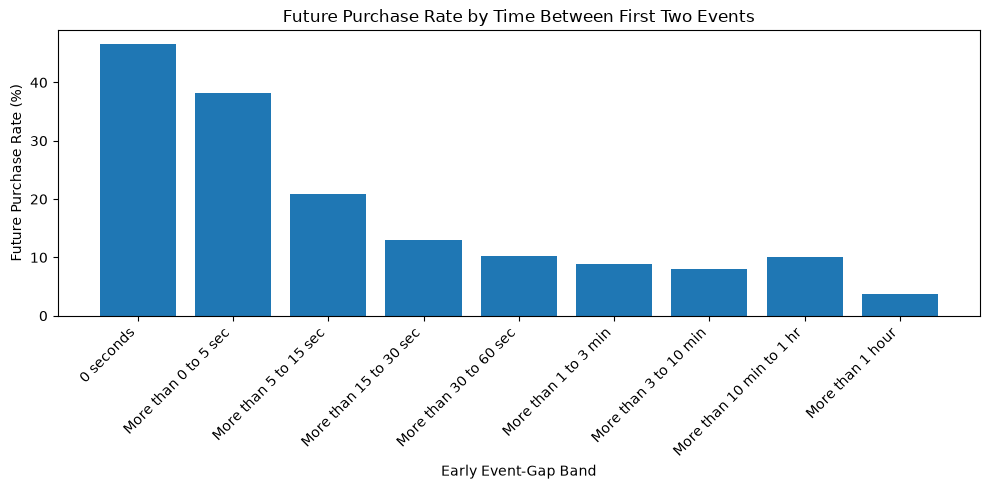

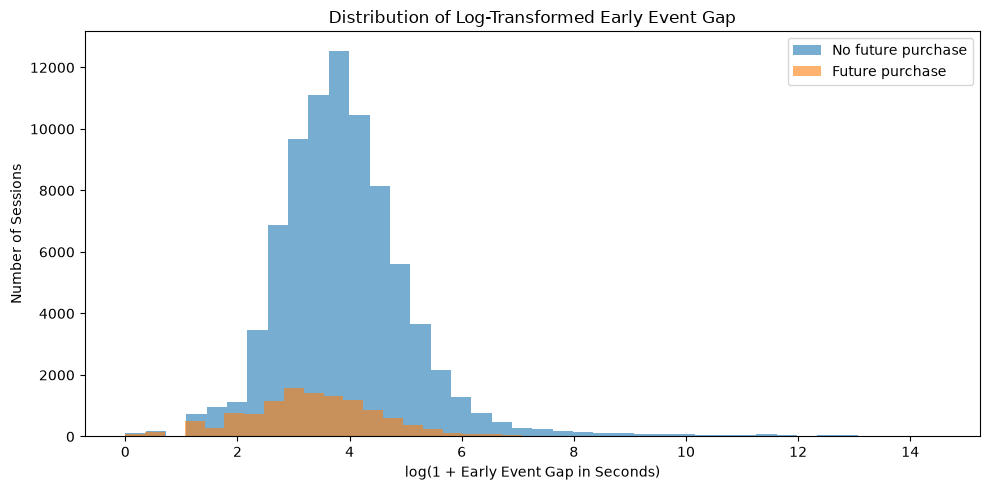

In [22]:
import matplotlib.pyplot as plt

early_gap_bins = [-0.01, 0, 5, 15, 30, 60, 180, 600, 3600, np.inf]

early_gap_labels = [
    "0 seconds",
    "More than 0 to 5 sec",
    "More than 5 to 15 sec",
    "More than 15 to 30 sec",
    "More than 30 to 60 sec",
    "More than 1 to 3 min",
    "More than 3 to 10 min",
    "More than 10 min to 1 hr",
    "More than 1 hour"
]

modeling_dataset["early_event_gap_band"] = pd.cut(
    modeling_dataset["early_event_gap_seconds"],
    bins=early_gap_bins,
    labels=early_gap_labels,
    include_lowest=True
)

early_gap_summary = (
    modeling_dataset
    .groupby("early_event_gap_band", observed=False)
    .agg(
        sessions=("user_session", "size"),
        future_purchase_sessions=("future_purchase", "sum"),
        future_purchase_rate=("future_purchase", "mean")
    )
    .reset_index()
)

early_gap_summary["future_purchase_rate"] = (
    early_gap_summary["future_purchase_rate"] * 100
)

print("Future Purchase by Time Between First Two Events")
display(early_gap_summary)

plt.figure(figsize=(10, 5))
plt.bar(
    early_gap_summary["early_event_gap_band"].astype(str),
    early_gap_summary["future_purchase_rate"]
)
plt.title("Future Purchase Rate by Time Between First Two Events")
plt.xlabel("Early Event-Gap Band")
plt.ylabel("Future Purchase Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))

for target_value, target_label in [
    (0, "No future purchase"),
    (1, "Future purchase")
]:
    subset = modeling_dataset.loc[
        modeling_dataset["future_purchase"].eq(target_value),
        "early_event_gap_log1p"
    ]

    plt.hist(
        subset,
        bins=40,
        alpha=0.6,
        label=target_label
    )

plt.title("Distribution of Log-Transformed Early Event Gap")
plt.xlabel("log(1 + Early Event Gap in Seconds)")
plt.ylabel("Number of Sessions")
plt.legend()
plt.tight_layout()
plt.show()

### Early Event-Gap Binning

The time gap between the first two session events showed a strong relationship with future purchase. Sessions with very short gaps had substantially higher future-purchase rates. Sessions with a 0-second gap had a future-purchase rate of 46.60%, while sessions with a gap of more than 0 to 5 seconds had a rate of 38.17%.

Future-purchase rates declined as the gap between the first two events increased. Sessions with gaps longer than one hour had a future-purchase rate of only 3.66%.

Because the event-gap distribution is highly skewed, a log-transformed version of the event gap, `early_event_gap_log1p`, will be retained as a candidate feature. The binned event-gap variable is used for EDA interpretation, while the log-transformed continuous version is used for modeling.

# Candidate Feature Inventory and Exclusion Justification

In [23]:
# Define candidate features for Step 3 feature engineering and Step 4 modeling handoff.

numeric_candidate_features = [
    "early_cart_count",
    "early_unique_products",
    "early_unique_categories",
    "early_unique_brands",
    "early_zero_price_event_count",
    "price_for_aggregation_first",
    "price_for_aggregation_second",
    "early_event_gap_log1p"
]

categorical_candidate_features = [
    "event_type_first",
    "event_type_second",
    "category_code_clean_first",
    "category_code_clean_second",
    "brand_clean_first",
    "brand_clean_second",
    "first_event_hour",
    "first_event_dayofweek",
    "first_event_is_weekend"
]

candidate_features = (
    numeric_candidate_features
    + categorical_candidate_features
)

TARGET_COLUMN = "future_purchase"
TIME_COLUMN = "first_event_time"
SESSION_COLUMN = "user_session"

# Validate required columns.
required_modeling_columns = (
    [SESSION_COLUMN, TIME_COLUMN, TARGET_COLUMN]
    + candidate_features
)

missing_modeling_columns = [
    column
    for column in required_modeling_columns
    if column not in modeling_dataset.columns
]

if missing_modeling_columns:
    raise KeyError(
        "Missing required modeling columns:\n"
        + "\n".join(missing_modeling_columns)
    )

# Standardize model-ready data types.
model_ready_data = modeling_dataset.copy()

for feature in numeric_candidate_features:
    model_ready_data[feature] = pd.to_numeric(
        model_ready_data[feature],
        errors="coerce"
    )

for feature in categorical_candidate_features:
    model_ready_data[feature] = (
        model_ready_data[feature]
        .astype("string")
        .fillna("unknown")
    )

model_ready_data[TIME_COLUMN] = pd.to_datetime(
    model_ready_data[TIME_COLUMN],
    errors="coerce",
    utc=True
)

# Candidate feature inventory.
candidate_feature_inventory = pd.DataFrame({
    "feature": candidate_features,
    "model_role": "Candidate predictor",
    "feature_type": [
        "Numeric" if feature in numeric_candidate_features else "Categorical"
        for feature in candidate_features
    ],
    "dtype_after_validation": [
        str(model_ready_data[feature].dtype)
        for feature in candidate_features
    ],
    "missing_count": [
        int(model_ready_data[feature].isna().sum())
        for feature in candidate_features
    ],
    "missing_percentage": [
        model_ready_data[feature].isna().mean() * 100
        for feature in candidate_features
    ],
    "unique_values": [
        int(model_ready_data[feature].nunique(dropna=True))
        for feature in candidate_features
    ],
    "planned_treatment": [
        (
            "Median imputation within training pipeline; scaling if needed."
            if feature in numeric_candidate_features
            else "Categorical encoding within training pipeline; handle unseen/infrequent values."
        )
        for feature in candidate_features
    ]
})

excluded_feature_justifications = pd.DataFrame({
    "feature": [
        "user_session",
        "total_session_events",
        "purchase_in_observation_window",
        "future_purchase",
        "observation_event_count",
        "early_view_count",
        "early_has_cart_event",
        "first_event_time",
        "second_event_time",
        "early_event_gap_seconds",
        "early_average_positive_price",
        "early_median_positive_price",
        "early_minimum_positive_price",
        "early_maximum_positive_price",
        "first_category_group",
        "early_event_pattern",
        "early_event_gap_band"
    ],
    "reason_for_exclusion": [
        "Traceability identifier only; not a predictive feature.",
        "Uses complete-session information after the prediction point.",
        "Leakage-control field; all retained sessions should have value 0.",
        "Target variable, not a predictor.",
        "Constant value of 2 after selecting the two-event observation window.",
        "Redundant with early_cart_count because the observation window contains two events.",
        "Redundant with early_cart_count.",
        "Raw timestamp excluded; derived hour, day-of-week, and event-gap features are used instead.",
        "Raw timestamp excluded; derived event-gap feature is used instead.",
        "Replaced by log-transformed early_event_gap_log1p to reduce skewness.",
        "Overlaps with first and second observed positive-price features.",
        "Overlaps with first and second observed positive-price features.",
        "Overlaps with first and second observed positive-price features.",
        "Overlaps with first and second observed positive-price features.",
        "EDA-only grouping derived from category_code_clean_first.",
        "EDA-only variable used for behavior-pattern interpretation.",
        "EDA-only binned feature used for interpretation; log-transformed continuous feature is retained."
    ]
})

print("Candidate Predictor Inventory")
display(candidate_feature_inventory)

print("Excluded Fields and Justifications")
display(excluded_feature_justifications)

FEATURE_INVENTORY_PATH = (
    PROCESSED_DATA_FOLDER
    / "leakage_safe_feature_inventory.csv"
)

candidate_feature_inventory.to_csv(
    FEATURE_INVENTORY_PATH,
    index=False
)

print("Saved feature inventory:")
print(FEATURE_INVENTORY_PATH)

Candidate Predictor Inventory


,feature,model_role,feature_type,dtype_after_validation,missing_count,missing_percentage,unique_values,planned_treatment
0,early_cart_count,Candidate predictor,Numeric,int8,0,0.000000,3,Median imputation within training pipeline; sc...
1,early_unique_products,Candidate predictor,Numeric,int64,0,0.000000,2,Median imputation within training pipeline; sc...
2,early_unique_categories,Candidate predictor,Numeric,int64,0,0.000000,2,Median imputation within training pipeline; sc...
3,early_unique_brands,Candidate predictor,Numeric,int64,0,0.000000,2,Median imputation within training pipeline; sc...
4,early_zero_price_event_count,Candidate predictor,Numeric,int8,0,0.000000,3,Median imputation within training pipeline; sc...
5,price_for_aggregation_first,Candidate predictor,Numeric,float64,63,0.067889,13598,Median imputation within training pipeline; sc...
6,price_for_aggregation_second,Candidate predictor,Numeric,float64,55,0.059268,14181,Median imputation within training pipeline; sc...
7,early_event_gap_log1p,Candidate predictor,Numeric,float64,0,0.000000,2675,Median imputation within training pipeline; sc...
8,event_type_first,Candidate predictor,Categorical,string,0,0.000000,2,Categorical encoding within training pipeline;...
9,event_type_second,Candidate predictor,Categorical,string,0,0.000000,2,Categorical encoding within training pipeline;...


Excluded Fields and Justifications


,feature,reason_for_exclusion
0,user_session,Traceability identifier only; not a predictive...
1,total_session_events,Uses complete-session information after the pr...
2,purchase_in_observation_window,Leakage-control field; all retained sessions s...
3,future_purchase,"Target variable, not a predictor."
4,observation_event_count,Constant value of 2 after selecting the two-ev...
5,early_view_count,Redundant with early_cart_count because the ob...
6,early_has_cart_event,Redundant with early_cart_count.
7,first_event_time,"Raw timestamp excluded; derived hour, day-of-w..."
8,second_event_time,Raw timestamp excluded; derived event-gap feat...
9,early_event_gap_seconds,Replaced by log-transformed early_event_gap_lo...


Saved feature inventory:
C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\leakage_safe_feature_inventory.csv


### Candidate Feature Inventory

A total of 17 leakage-safe candidate predictors were defined for feature engineering and model handoff. These include 8 numeric features and 9 categorical features derived only from the first two events of each eligible session.

Numeric features include early cart count, product/category/brand diversity, zero-price event count, first and second observed positive prices, and the log-transformed gap between the first two events. Categorical features include first and second event type, first and second product category, first and second brand, and time-based features.

Most candidate features had no missing values. The only missing values appeared in the first and second price fields, where some early events had zero or non-positive prices that were intentionally excluded from price aggregation. These missing values will be handled through median imputation inside the training pipeline.

Several fields were excluded to prevent leakage or redundancy. Complete-session variables, raw timestamps, identifiers, target fields, and EDA-only grouped or binned variables were not included as candidate predictors.

# Create Chronological Train-Validation-Test Split

In [24]:
# Create a controlled model-ready dataset for analysis.
model_ready_columns = (
    [SESSION_COLUMN, TIME_COLUMN, TARGET_COLUMN]
    + candidate_features
)

model_ready_data = model_ready_data[model_ready_columns].copy()

if model_ready_data[TIME_COLUMN].isna().any():
    raise ValueError("Invalid first_event_time values were found.")

if model_ready_data[SESSION_COLUMN].duplicated().any():
    raise ValueError("Duplicate user_session values were found.")

if model_ready_data[TARGET_COLUMN].isna().any():
    raise ValueError("Missing future_purchase target labels were found.")

# Sort chronologically by prediction time.
split_source = (
    model_ready_data
    .sort_values(
        by=[TIME_COLUMN, SESSION_COLUMN],
        kind="stable"
    )
    .reset_index(drop=True)
)

total_modeling_sessions = len(split_source)

train_cut_index = int(total_modeling_sessions * 0.70)
validation_cut_index = int(total_modeling_sessions * 0.85)

train_end_time = split_source.iloc[train_cut_index - 1][TIME_COLUMN]
validation_end_time = split_source.iloc[
    validation_cut_index - 1
][TIME_COLUMN]

train_data = split_source.loc[
    split_source[TIME_COLUMN].le(train_end_time)
].copy()

validation_data = split_source.loc[
    split_source[TIME_COLUMN].gt(train_end_time)
    & split_source[TIME_COLUMN].le(validation_end_time)
].copy()

test_data = split_source.loc[
    split_source[TIME_COLUMN].gt(validation_end_time)
].copy()

X_train = train_data[candidate_features].copy()
y_train = train_data[TARGET_COLUMN].copy()

X_validation = validation_data[candidate_features].copy()
y_validation = validation_data[TARGET_COLUMN].copy()

X_test = test_data[candidate_features].copy()
y_test = test_data[TARGET_COLUMN].copy()

def summarize_split(split_name, dataframe):
    return {
        "split": split_name,
        "sessions": len(dataframe),
        "percentage_of_all_sessions": round(
            len(dataframe) / total_modeling_sessions * 100,
            2
        ),
        "future_purchase_sessions": int(
            dataframe[TARGET_COLUMN].sum()
        ),
        "future_purchase_rate_percent": round(
            dataframe[TARGET_COLUMN].mean() * 100,
            2
        ),
        "first_prediction_time": dataframe[TIME_COLUMN].min(),
        "last_prediction_time": dataframe[TIME_COLUMN].max()
    }

split_summary = pd.DataFrame([
    summarize_split("Training", train_data),
    summarize_split("Validation", validation_data),
    summarize_split("Test", test_data)
])

print("Chronological Train-Validation-Test Split")
display(split_summary)

assert train_data[TIME_COLUMN].max() < validation_data[TIME_COLUMN].min()
assert validation_data[TIME_COLUMN].max() < test_data[TIME_COLUMN].min()

assert set(train_data[SESSION_COLUMN]).isdisjoint(
    set(validation_data[SESSION_COLUMN])
)

assert set(train_data[SESSION_COLUMN]).isdisjoint(
    set(test_data[SESSION_COLUMN])
)

assert set(validation_data[SESSION_COLUMN]).isdisjoint(
    set(test_data[SESSION_COLUMN])
)

print("Chronological split validation checks passed.")

Chronological Train-Validation-Test Split


,split,sessions,percentage_of_all_sessions,future_purchase_sessions,future_purchase_rate_percent,first_prediction_time,last_prediction_time
0,Training,64959,70.0,7974,12.28,2020-04-01 00:00:53+00:00,2020-04-23 10:45:02+00:00
1,Validation,13920,15.0,1834,13.18,2020-04-23 10:45:05+00:00,2020-04-27 06:58:38+00:00
2,Test,13920,15.0,1867,13.41,2020-04-27 06:58:53+00:00,2020-04-30 23:58:40+00:00


Chronological split validation checks passed.


## 3b. Correlation Analysis

Correlation analysis is performed using the training dataset only to avoid learning patterns from the validation and test periods.

Because the modeling dataset contains a mix of numeric and categorical features, the formal correlation matrix focuses on numeric candidate predictors. Relationships between categorical variables and the target were already examined through grouped EDA tables such as event pattern, category, brand, and temporal summaries.

# Numeric Correlation Analysis Using Training Data Only

Numeric Feature Correlation with Future Purchase


,numeric_feature,spearman_correlation_with_future_purchase,absolute_correlation
0,early_cart_count,0.455641,0.455641
1,early_unique_products,-0.200831,0.200831
2,early_event_gap_log1p,-0.142036,0.142036
3,early_unique_brands,-0.134550,0.134550
4,early_unique_categories,-0.100067,0.100067
5,early_zero_price_event_count,-0.010659,0.010659
6,price_for_aggregation_first,0.003792,0.003792
7,price_for_aggregation_second,-0.001836,0.001836


Numeric Feature Spearman Correlation Matrix


,early_cart_count,early_unique_products,early_unique_categories,early_unique_brands,early_zero_price_event_count,price_for_aggregation_first,price_for_aggregation_second,early_event_gap_log1p,future_purchase
early_cart_count,1.000000,-0.411344,-0.140062,-0.241469,-0.006584,0.015156,0.010869,-0.255328,0.455641
early_unique_products,-0.411344,1.000000,0.341363,0.587521,0.013508,-0.047386,-0.037100,0.224202,-0.200831
early_unique_categories,-0.140062,0.341363,1.000000,0.424686,0.012619,-0.104092,-0.113973,0.252609,-0.100067
early_unique_brands,-0.241469,0.587521,0.424686,1.000000,0.011646,-0.142886,-0.143964,0.221231,-0.134550
early_zero_price_event_count,-0.006584,0.013508,0.012619,0.011646,1.000000,-0.006251,-0.009604,0.004113,-0.010659
price_for_aggregation_first,0.015156,-0.047386,-0.104092,-0.142886,-0.006251,1.000000,0.839565,0.011976,0.003792
price_for_aggregation_second,0.010869,-0.037100,-0.113973,-0.143964,-0.009604,0.839565,1.000000,0.007655,-0.001836
early_event_gap_log1p,-0.255328,0.224202,0.252609,0.221231,0.004113,0.011976,0.007655,1.000000,-0.142036
future_purchase,0.455641,-0.200831,-0.100067,-0.134550,-0.010659,0.003792,-0.001836,-0.142036,1.000000


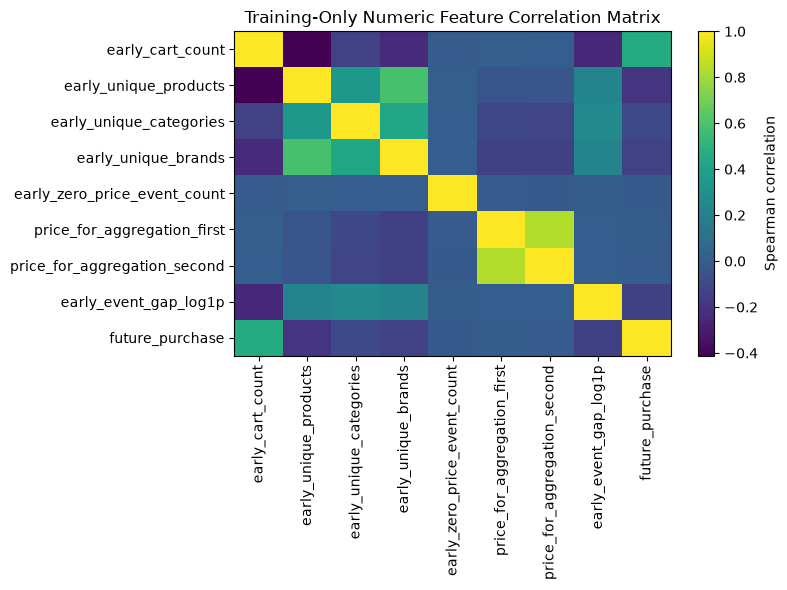

Saved correlation outputs:
C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\step3_training_numeric_target_correlation.csv
C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\step3_training_numeric_correlation_matrix.csv


In [25]:
import matplotlib.pyplot as plt

# Use training data only to avoid validation/test leakage.
numeric_correlation_data = train_data[
    numeric_candidate_features + [TARGET_COLUMN]
].copy()

# Spearman is used because several numeric features are skewed or count-based.
numeric_spearman_correlation = (
    numeric_correlation_data
    .corr(method="spearman")
)

target_correlation_summary = (
    numeric_spearman_correlation[[TARGET_COLUMN]]
    .drop(index=TARGET_COLUMN)
    .rename(columns={TARGET_COLUMN: "spearman_correlation_with_future_purchase"})
    .assign(
        absolute_correlation=lambda df: (
            df["spearman_correlation_with_future_purchase"].abs()
        )
    )
    .sort_values("absolute_correlation", ascending=False)
    .reset_index()
    .rename(columns={"index": "numeric_feature"})
)

print("Numeric Feature Correlation with Future Purchase")
display(target_correlation_summary)

print("Numeric Feature Spearman Correlation Matrix")
display(numeric_spearman_correlation)

plt.figure(figsize=(8, 6))
plt.imshow(numeric_spearman_correlation, aspect="auto")
plt.colorbar(label="Spearman correlation")
plt.xticks(
    ticks=np.arange(len(numeric_spearman_correlation.columns)),
    labels=numeric_spearman_correlation.columns,
    rotation=90
)
plt.yticks(
    ticks=np.arange(len(numeric_spearman_correlation.index)),
    labels=numeric_spearman_correlation.index
)
plt.title("Training-Only Numeric Feature Correlation Matrix")
plt.tight_layout()
plt.show()

CORRELATION_SUMMARY_PATH = (
    PROCESSED_DATA_FOLDER
    / "step3_training_numeric_target_correlation.csv"
)

CORRELATION_MATRIX_PATH = (
    PROCESSED_DATA_FOLDER
    / "step3_training_numeric_correlation_matrix.csv"
)

target_correlation_summary.to_csv(
    CORRELATION_SUMMARY_PATH,
    index=False
)

numeric_spearman_correlation.to_csv(
    CORRELATION_MATRIX_PATH
)

print("Saved correlation outputs:")
print(CORRELATION_SUMMARY_PATH)
print(CORRELATION_MATRIX_PATH)

### Numeric Correlation Analysis

A training-only Spearman correlation analysis was performed on the numeric candidate features. Spearman correlation was used because several engineered features are count-based or skewed.

The strongest numeric relationship with the target was `early_cart_count`, with a Spearman correlation of 0.4556. This supports the earlier EDA finding that cart activity within the first two events is strongly associated with future purchase.

Several diversity and timing features had negative correlations with future purchase. `early_unique_products`, `early_unique_brands`, `early_unique_categories`, and `early_event_gap_log1p` were negatively correlated with the target. This suggests that sessions with more focused early behavior and shorter gaps between the first two events are more likely to purchase later.

The first and second price features had weak direct monotonic correlation with future purchase. However, they are still retained as candidate predictors because price may interact with product category, brand, and event type in non-linear models.

The first and second price features were highly correlated with each other, which is expected because the first two events often involve related products. This will be handled during model implementation and feature selection.

## 3e. Dimensionality Reduction: PCA

PCA is applied as an exploratory dimensionality-reduction technique. Because the dataset contains both numeric and categorical features, preprocessing is required before PCA.

The preprocessing and PCA transformation are fitted only on the training dataset to prevent leakage from the validation and test periods. PCA is used for visualization and interpretation only. The original engineered features remain the official feature set for model implementation unless PCA-based modeling is explicitly tested there.

In [26]:
import inspect

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# OneHotEncoder parameter compatibility across scikit-learn versions.
one_hot_parameters = {
    "handle_unknown": "infrequent_if_exist",
    "min_frequency": 50
}

if "sparse_output" in inspect.signature(OneHotEncoder).parameters:
    one_hot_parameters["sparse_output"] = False
else:
    one_hot_parameters["sparse"] = False

pca_numeric_pipeline = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

pca_categorical_pipeline = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="unknown"
        )
    ),
    (
        "encoder",
        OneHotEncoder(**one_hot_parameters)
    )
])

pca_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            pca_numeric_pipeline,
            numeric_candidate_features
        ),
        (
            "categorical",
            pca_categorical_pipeline,
            categorical_candidate_features
        )
    ],
    remainder="drop"
)

# Fit preprocessing only on training data.
X_train_preprocessed_for_pca = pca_preprocessor.fit_transform(X_train)

# Fit PCA only on training data.
pca_model = PCA(random_state=RANDOM_STATE)

X_train_pca = pca_model.fit_transform(X_train_preprocessed_for_pca)

pca_explained_variance = pd.DataFrame({
    "principal_component": [
        f"PC{i + 1}"
        for i in range(len(pca_model.explained_variance_ratio_))
    ],
    "explained_variance_ratio": pca_model.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(
        pca_model.explained_variance_ratio_
    )
})

components_to_show = min(20, len(pca_explained_variance))

print("PCA Explained Variance Summary - First 20 Components")
display(pca_explained_variance.head(components_to_show))

components_for_80_percent = int(
    np.argmax(
        pca_explained_variance["cumulative_explained_variance"].ge(0.80)
    ) + 1
)

components_for_90_percent = int(
    np.argmax(
        pca_explained_variance["cumulative_explained_variance"].ge(0.90)
    ) + 1
)

pca_summary = pd.DataFrame({
    "metric": [
        "Training rows used for PCA",
        "Preprocessed feature count",
        "PC1 explained variance",
        "PC2 explained variance",
        "PC1 + PC2 cumulative explained variance",
        "Components needed for at least 80% variance",
        "Components needed for at least 90% variance"
    ],
    "value": [
        f"{X_train_preprocessed_for_pca.shape[0]:,}",
        f"{X_train_preprocessed_for_pca.shape[1]:,}",
        f"{pca_model.explained_variance_ratio_[0]:.4f}",
        f"{pca_model.explained_variance_ratio_[1]:.4f}",
        f"{pca_explained_variance.loc[1, 'cumulative_explained_variance']:.4f}",
        components_for_80_percent,
        components_for_90_percent
    ]
})

print("PCA Summary")
display(pca_summary)

PCA_EXPLAINED_VARIANCE_PATH = (
    PROCESSED_DATA_FOLDER
    / "step3_training_pca_explained_variance.csv"
)

pca_explained_variance.to_csv(
    PCA_EXPLAINED_VARIANCE_PATH,
    index=False
)

print("Saved PCA explained variance:")
print(PCA_EXPLAINED_VARIANCE_PATH)

PCA Explained Variance Summary - First 20 Components


,principal_component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.168931,0.168931
1,PC2,0.128983,0.297914
2,PC3,0.071233,0.369147
3,PC4,0.070761,0.439908
4,PC5,0.063642,0.503550
5,PC6,0.043529,0.547080
6,PC7,0.036982,0.584062
7,PC8,0.035010,0.619072
8,PC9,0.024596,0.643669
9,PC10,0.018435,0.662104


PCA Summary


,metric,value
0,Training rows used for PCA,"64,959"
1,Preprocessed feature count,511
2,PC1 explained variance,0.1689
3,PC2 explained variance,0.1290
4,PC1 + PC2 cumulative explained variance,0.2979
5,Components needed for at least 80% variance,26
6,Components needed for at least 90% variance,62


Saved PCA explained variance:
C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\step3_training_pca_explained_variance.csv


### PCA Explained Variance

PCA was applied using training data only after preprocessing the numeric and categorical candidate features. The preprocessing produced 511 transformed features from the original leakage-safe candidate predictors.

The first principal component explained 16.89% of the variance, while the second principal component explained 12.90%. Together, the first two principal components explained 29.79% of the total transformed feature variance.

A total of 26 principal components were required to explain at least 80% of the variance, and 62 components were required to explain at least 90%. This indicates that the transformed feature space cannot be represented well using only one or two dimensions.

This result is expected because the dataset contains high-cardinality categorical variables such as brand and category, which are represented through one-hot encoding. PCA is therefore useful as an exploratory dimensionality-reduction tool, but it will not replace the original engineered features for the main model implementation.

# PCA Visualization of Training Data

PCA Plot Sample Class Summary


,target_group,sessions,median_pc1,median_pc2,mean_pc1,mean_pc2
0,No future purchase,17466,0.047198,-0.324898,0.167474,0.057297
1,Future purchase,2534,-1.364028,-0.696173,-1.236695,-0.420561


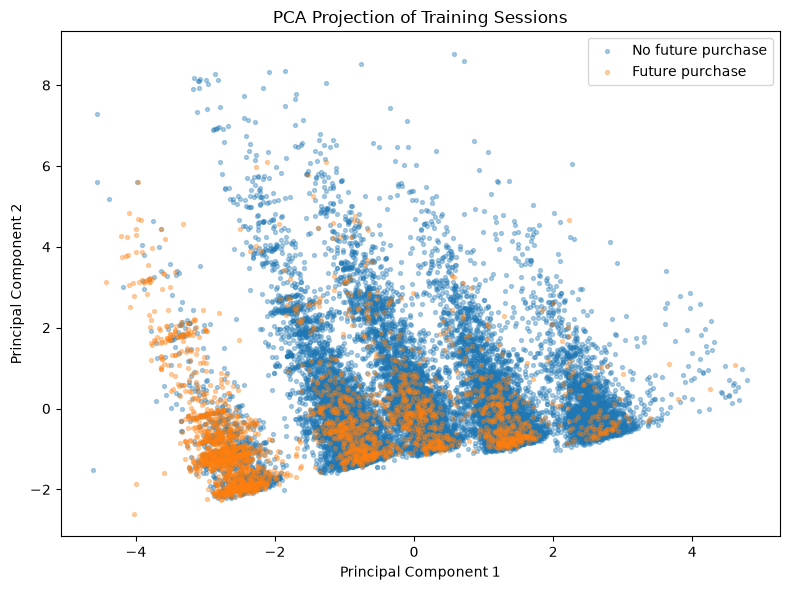

Saved PCA plot sample:
C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\step3_training_pca_plot_sample.csv


In [27]:
# Create a manageable PCA visualization sample from the training set.
PCA_PLOT_SAMPLE_SIZE = min(20_000, len(train_data))

pca_plot_sample = (
    train_data
    .sample(
        n=PCA_PLOT_SAMPLE_SIZE,
        random_state=RANDOM_STATE
    )
    .copy()
)

X_pca_plot_sample = pca_preprocessor.transform(
    pca_plot_sample[candidate_features]
)

X_pca_plot_coordinates = pca_model.transform(
    X_pca_plot_sample
)

pca_plot_data = pd.DataFrame({
    "PC1": X_pca_plot_coordinates[:, 0],
    "PC2": X_pca_plot_coordinates[:, 1],
    "future_purchase": pca_plot_sample[TARGET_COLUMN].to_numpy()
})

pca_class_summary = (
    pca_plot_data
    .groupby("future_purchase")
    .agg(
        sessions=("future_purchase", "size"),
        median_pc1=("PC1", "median"),
        median_pc2=("PC2", "median"),
        mean_pc1=("PC1", "mean"),
        mean_pc2=("PC2", "mean")
    )
    .reset_index()
)

pca_class_summary["target_group"] = (
    pca_class_summary["future_purchase"]
    .map({
        0: "No future purchase",
        1: "Future purchase"
    })
)

pca_class_summary = pca_class_summary[
    [
        "target_group",
        "sessions",
        "median_pc1",
        "median_pc2",
        "mean_pc1",
        "mean_pc2"
    ]
]

print("PCA Plot Sample Class Summary")
display(pca_class_summary)

plt.figure(figsize=(8, 6))

for target_value, target_label in [
    (0, "No future purchase"),
    (1, "Future purchase")
]:
    subset = pca_plot_data.loc[
        pca_plot_data["future_purchase"].eq(target_value)
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        s=8,
        alpha=0.35,
        label=target_label
    )

plt.title("PCA Projection of Training Sessions")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

PCA_PLOT_DATA_PATH = (
    PROCESSED_DATA_FOLDER
    / "step3_training_pca_plot_sample.csv"
)

pca_plot_data.to_csv(
    PCA_PLOT_DATA_PATH,
    index=False
)

print("Saved PCA plot sample:")
print(PCA_PLOT_DATA_PATH)

### PCA Visualization

The PCA projection showed partial separation between future-purchase and non-purchase sessions, but the two groups still overlapped substantially in the first two principal components.

Future-purchase sessions had lower median and mean values on both PC1 and PC2 compared with non-purchase sessions. This suggests that PCA captured some structure related to purchase propensity, but the first two components alone are not sufficient to clearly separate the target classes.

Because PC1 and PC2 explain only 29.79% of the transformed feature variance and the plotted classes overlap, PCA will be treated as an exploratory dimensionality-reduction method only. The original engineered features remain more interpretable and more appropriate for formal model implementation.

## 3d. Feature Selection: Embedded L1 Logistic Regression

Embedded feature selection is performed using an L1-regularized Logistic Regression model fitted only on the chronological training dataset.

The purpose of this model is feature selection, not final model implementation.

# Training-Only Embedded L1 Feature Selection

In [29]:
from sklearn.linear_model import LogisticRegression

# Preprocessing for embedded feature selection.
# Numeric features are imputed and scaled.
# Categorical features are imputed and one-hot encoded.
feature_selection_numeric_pipeline = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    ),
    (
        "scaler",
        StandardScaler(with_mean=False)
    )
])

feature_selection_categorical_pipeline = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="unknown"
        )
    ),
    (
        "encoder",
        OneHotEncoder(**one_hot_parameters)
    )
])

feature_selection_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            feature_selection_numeric_pipeline,
            numeric_candidate_features
        ),
        (
            "categorical",
            feature_selection_categorical_pipeline,
            categorical_candidate_features
        )
    ],
    remainder="drop",
    sparse_threshold=0.3
)

# l1_ratio=1.0 is used for L1-style regularization.
# This avoids older penalty='l1' syntax warnings in newer scikit-learn versions.
l1_feature_selector = LogisticRegression(
    solver="saga",
    l1_ratio=1.0,
    C=0.05,
    class_weight="balanced",
    max_iter=4000,
    random_state=RANDOM_STATE
)

feature_selection_pipeline = Pipeline(steps=[
    ("preprocessor", feature_selection_preprocessor),
    ("model", l1_feature_selector)
])

feature_selection_pipeline.fit(X_train, y_train)

fitted_feature_selection_preprocessor = (
    feature_selection_pipeline.named_steps["preprocessor"]
)

fitted_l1_model = feature_selection_pipeline.named_steps["model"]

transformed_feature_names = (
    fitted_feature_selection_preprocessor.get_feature_names_out()
)

l1_coefficients = fitted_l1_model.coef_[0]

embedded_l1_feature_selection_report = pd.DataFrame({
    "transformed_feature": transformed_feature_names,
    "l1_coefficient": l1_coefficients
})

embedded_l1_feature_selection_report["absolute_coefficient"] = (
    embedded_l1_feature_selection_report["l1_coefficient"].abs()
)

embedded_l1_feature_selection_report["selected_by_l1"] = (
    embedded_l1_feature_selection_report["absolute_coefficient"].gt(1e-8)
)

def map_transformed_feature_to_source(transformed_feature, raw_features):
    clean_name = transformed_feature.split("__", maxsplit=1)[-1]

    if clean_name.startswith("missingindicator_"):
        clean_name = clean_name.replace("missingindicator_", "")

    for raw_feature in sorted(raw_features, key=len, reverse=True):
        if clean_name == raw_feature or clean_name.startswith(f"{raw_feature}_"):
            return raw_feature

    return "derived_or_imputation_indicator"

embedded_l1_feature_selection_report["source_feature"] = (
    embedded_l1_feature_selection_report["transformed_feature"]
    .apply(
        lambda feature: map_transformed_feature_to_source(
            feature,
            candidate_features
        )
    )
)

embedded_l1_feature_selection_report["association_direction"] = np.where(
    embedded_l1_feature_selection_report["l1_coefficient"].gt(0),
    "Positive association with future purchase",
    np.where(
        embedded_l1_feature_selection_report["l1_coefficient"].lt(0),
        "Negative association with future purchase",
        "Coefficient shrunk to zero"
    )
)

embedded_l1_feature_selection_report = (
    embedded_l1_feature_selection_report
    .sort_values("absolute_coefficient", ascending=False)
    .reset_index(drop=True)
)

raw_feature_retention_summary = (
    embedded_l1_feature_selection_report
    .groupby("source_feature", as_index=False)
    .agg(
        transformed_features=("transformed_feature", "size"),
        selected_transformed_features=("selected_by_l1", "sum"),
        strongest_absolute_coefficient=("absolute_coefficient", "max")
    )
)

raw_feature_retention_summary["raw_feature_retained"] = (
    raw_feature_retention_summary["selected_transformed_features"].gt(0)
)

raw_feature_retention_summary = (
    raw_feature_retention_summary
    .sort_values(
        ["raw_feature_retained", "strongest_absolute_coefficient"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

selected_raw_features = (
    raw_feature_retention_summary
    .loc[
        raw_feature_retention_summary["raw_feature_retained"],
        "source_feature"
    ]
    .tolist()
)

# Keep only original candidate features. This removes any derived imputation indicator label
# if it appears as a separate mapped source.
selected_raw_features = [
    feature
    for feature in selected_raw_features
    if feature in candidate_features
]

excluded_raw_features_after_selection = [
    feature
    for feature in candidate_features
    if feature not in selected_raw_features
]

feature_selection_summary = pd.DataFrame({
    "metric": [
        "Original candidate raw features",
        "Transformed features evaluated",
        "Transformed features selected by L1",
        "Percentage of transformed features selected",
        "Raw candidate features retained",
        "Raw candidate features excluded"
    ],
    "value": [
        len(candidate_features),
        len(embedded_l1_feature_selection_report),
        int(embedded_l1_feature_selection_report["selected_by_l1"].sum()),
        (
            embedded_l1_feature_selection_report["selected_by_l1"].mean()
            * 100
        ),
        len(selected_raw_features),
        len(excluded_raw_features_after_selection)
    ]
})

print("Embedded L1 Feature-Selection Summary")
display(feature_selection_summary)

print("Top Selected Transformed Features")
display(
    embedded_l1_feature_selection_report
    .loc[embedded_l1_feature_selection_report["selected_by_l1"]]
    .head(30)
)

print("Raw Feature Retention Summary")
display(raw_feature_retention_summary)

print("Selected raw features:")
print(selected_raw_features)

print("Excluded raw features:")
print(excluded_raw_features_after_selection)

Embedded L1 Feature-Selection Summary


,metric,value
0,Original candidate raw features,17.000000
1,Transformed features evaluated,513.000000
2,Transformed features selected by L1,105.000000
3,Percentage of transformed features selected,20.467836
4,Raw candidate features retained,16.000000
5,Raw candidate features excluded,1.000000


Top Selected Transformed Features


,transformed_feature,l1_coefficient,absolute_coefficient,selected_by_l1,source_feature,association_direction
0,numeric__early_cart_count,0.796476,0.796476,True,early_cart_count,Positive association with future purchase
1,categorical__first_event_dayofweek_0,-0.602568,0.602568,True,first_event_dayofweek,Negative association with future purchase
2,categorical__first_event_dayofweek_1,-0.589572,0.589572,True,first_event_dayofweek,Negative association with future purchase
3,categorical__brand_clean_second_arg,0.412243,0.412243,True,brand_clean_second,Positive association with future purchase
4,categorical__category_code_clean_second_constr...,0.392158,0.392158,True,category_code_clean_second,Positive association with future purchase
5,categorical__brand_clean_second_lg,0.366981,0.366981,True,brand_clean_second,Positive association with future purchase
6,categorical__category_code_clean_second_applia...,0.335326,0.335326,True,category_code_clean_second,Positive association with future purchase
7,categorical__brand_clean_second_defacto,-0.305481,0.305481,True,brand_clean_second,Negative association with future purchase
8,categorical__first_event_hour_20,-0.292020,0.292020,True,first_event_hour,Negative association with future purchase
9,categorical__first_event_hour_1,-0.291303,0.291303,True,first_event_hour,Negative association with future purchase


Raw Feature Retention Summary


,source_feature,transformed_features,selected_transformed_features,strongest_absolute_coefficient,raw_feature_retained
0,early_cart_count,1,1,0.796476,True
1,first_event_dayofweek,7,6,0.602568,True
2,brand_clean_second,145,19,0.412243,True
3,category_code_clean_second,92,22,0.392158,True
4,first_event_hour,24,20,0.292020,True
5,category_code_clean_first,92,14,0.269117,True
6,price_for_aggregation_second,2,2,0.260281,True
7,early_unique_categories,1,1,0.158297,True
8,brand_clean_first,137,13,0.157312,True
9,early_event_gap_log1p,1,1,0.066799,True


Selected raw features:
['early_cart_count', 'first_event_dayofweek', 'brand_clean_second', 'category_code_clean_second', 'first_event_hour', 'category_code_clean_first', 'price_for_aggregation_second', 'early_unique_categories', 'brand_clean_first', 'early_event_gap_log1p', 'early_unique_brands', 'price_for_aggregation_first', 'early_zero_price_event_count', 'early_unique_products', 'event_type_second', 'first_event_is_weekend']
Excluded raw features:
['event_type_first']


### Embedded Feature Selection

Embedded feature selection was performed using an L1-regularized Logistic Regression model fitted only on the chronological training dataset. The purpose of this model was feature selection, not final model implementation.

The feature-selection process evaluated 17 original candidate raw features, which expanded into 513 transformed features after preprocessing and one-hot encoding. L1 regularization selected 105 transformed features and retained 16 of the 17 raw candidate features.

The only excluded raw feature was `event_type_first`, suggesting that the first event type contributed limited additional predictive signal after considering early cart activity, second event type, product context, price, timing, and temporal variables.

The strongest retained feature was `early_cart_count`, which supports the EDA finding that cart activity within the first two session events is a strong indicator of future purchase intent.

# Save Feature Selection Reports and Model-Ready Dataset

In [33]:
# Preserve the original candidate feature order after L1 selection.
retained_raw_features = [
    feature
    for feature in candidate_features
    if feature in selected_raw_features
]

excluded_raw_features_after_selection = [
    feature
    for feature in candidate_features
    if feature not in retained_raw_features
]

retained_numeric_features = [
    feature
    for feature in numeric_candidate_features
    if feature in retained_raw_features
]

retained_categorical_features = [
    feature
    for feature in categorical_candidate_features
    if feature in retained_raw_features
]

# Add selection status to the feature inventory.
final_feature_inventory = candidate_feature_inventory.copy()

final_feature_inventory["selected_by_l1_feature_selection"] = (
    final_feature_inventory["feature"].isin(retained_raw_features)
)

final_feature_inventory["selection_status"] = np.where(
    final_feature_inventory["selected_by_l1_feature_selection"],
    "Retained for Step 4 model implementation",
    "Excluded after embedded L1 feature selection"
)

# Create the final model-ready dataset for Step 4.
# This contains only traceability fields, the prediction timestamp,
# the target, and the selected leakage-safe predictors.
final_model_ready_columns = (
    [SESSION_COLUMN, TIME_COLUMN, TARGET_COLUMN]
    + retained_raw_features
)

final_model_ready_data = model_ready_data[
    final_model_ready_columns
].copy()

# Validate final model-ready dataset.
model_ready_validation = pd.DataFrame({
    "check": [
        "Final model-ready sessions",
        "Target column",
        "Retained raw features",
        "Retained numeric features",
        "Retained categorical features",
        "Excluded raw features",
        "Duplicate session rows",
        "Missing target labels",
        "Invalid prediction timestamps",
        "Future-purchase sessions",
        "Future non-purchase sessions",
        "Future-purchase rate"
    ],
    "value": [
        f"{len(final_model_ready_data):,}",
        TARGET_COLUMN,
        len(retained_raw_features),
        len(retained_numeric_features),
        len(retained_categorical_features),
        len(excluded_raw_features_after_selection),
        f"{final_model_ready_data[SESSION_COLUMN].duplicated().sum():,}",
        f"{final_model_ready_data[TARGET_COLUMN].isna().sum():,}",
        f"{final_model_ready_data[TIME_COLUMN].isna().sum():,}",
        f"{final_model_ready_data[TARGET_COLUMN].sum():,}",
        f"{(final_model_ready_data[TARGET_COLUMN] == 0).sum():,}",
        f"{final_model_ready_data[TARGET_COLUMN].mean():.2%}"
    ]
})

print("Final Model-Ready Dataset Validation")
display(model_ready_validation)

print("Retained Raw Features for Model Implementation")
display(pd.DataFrame({
    "retained_feature": retained_raw_features,
    "feature_type": [
        "Numeric" if feature in retained_numeric_features else "Categorical"
        for feature in retained_raw_features
    ]
}))

print("Excluded Raw Features After L1 Feature Selection")
display(pd.DataFrame({
    "excluded_feature": excluded_raw_features_after_selection
}))

# Save Step 3 outputs.
FEATURE_SELECTION_REPORT_PATH = (
    PROCESSED_DATA_FOLDER
    / "training_only_embedded_l1_feature_selection_report.csv"
)

RAW_FEATURE_RETENTION_PATH = (
    PROCESSED_DATA_FOLDER
    / "training_only_raw_feature_retention_summary.csv"
)

FINAL_FEATURE_INVENTORY_PATH = (
    PROCESSED_DATA_FOLDER
    / "leakage_safe_feature_inventory_with_selection_status.csv"
)

MODEL_READY_DATA_PATH = (
    PROCESSED_DATA_FOLDER
    / "leakage_safe_modeling_dataset_ready_for_split.csv"
)

MODEL_READY_VALIDATION_PATH = (
    PROCESSED_DATA_FOLDER
    / "step3_model_ready_dataset_validation.csv"
)

embedded_l1_feature_selection_report.to_csv(
    FEATURE_SELECTION_REPORT_PATH,
    index=False
)

raw_feature_retention_summary.to_csv(
    RAW_FEATURE_RETENTION_PATH,
    index=False
)

final_feature_inventory.to_csv(
    FINAL_FEATURE_INVENTORY_PATH,
    index=False
)

final_model_ready_data.to_csv(
    MODEL_READY_DATA_PATH,
    index=False
)

model_ready_validation.to_csv(
    MODEL_READY_VALIDATION_PATH,
    index=False
)

# Critical validation checks.
assert final_model_ready_data[SESSION_COLUMN].duplicated().sum() == 0
assert final_model_ready_data[TARGET_COLUMN].isna().sum() == 0
assert final_model_ready_data[TIME_COLUMN].isna().sum() == 0
assert len(retained_raw_features) > 0
assert TARGET_COLUMN not in retained_raw_features
assert SESSION_COLUMN not in retained_raw_features
assert TIME_COLUMN not in retained_raw_features

print("Saved Step 3 feature-selection and model-ready outputs:")
print(f"- L1 feature-selection report: {FEATURE_SELECTION_REPORT_PATH}")
print(f"- Raw feature-retention summary: {RAW_FEATURE_RETENTION_PATH}")
print(f"- Feature inventory with selection status: {FINAL_FEATURE_INVENTORY_PATH}")
print(f"- Model-ready dataset for Model Implementation: {MODEL_READY_DATA_PATH}")
print(f"- Model-ready validation summary: {MODEL_READY_VALIDATION_PATH}")

print("\nStep 3 model-ready dataset successfully.")

Final Model-Ready Dataset Validation


,check,value
0,Final model-ready sessions,"92,799"
1,Target column,future_purchase
2,Retained raw features,16
3,Retained numeric features,8
4,Retained categorical features,8
5,Excluded raw features,1
6,Duplicate session rows,0
7,Missing target labels,0
8,Invalid prediction timestamps,0
9,Future-purchase sessions,"11,675"


Retained Raw Features for Model Implementation


,retained_feature,feature_type
0,early_cart_count,Numeric
1,early_unique_products,Numeric
2,early_unique_categories,Numeric
3,early_unique_brands,Numeric
4,early_zero_price_event_count,Numeric
5,price_for_aggregation_first,Numeric
6,price_for_aggregation_second,Numeric
7,early_event_gap_log1p,Numeric
8,event_type_second,Categorical
9,category_code_clean_first,Categorical


Excluded Raw Features After L1 Feature Selection


,excluded_feature
0,event_type_first


Saved Step 3 feature-selection and model-ready outputs:
- L1 feature-selection report: C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\training_only_embedded_l1_feature_selection_report.csv
- Raw feature-retention summary: C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\training_only_raw_feature_retention_summary.csv
- Feature inventory with selection status: C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\leakage_safe_feature_inventory_with_selection_status.csv
- Model-ready dataset for Model Implementation: C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\leakage_safe_modeling_dataset_ready_for_split.csv
- Model-ready validation summary: C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\step3_model_ready_dataset_validation.csv

Step 3 model-ready dataset successfully.


# Step 3 Conclusion: Data Preprocessing, Applied EDA, and Feature Engineering

Step 3 prepared the eCommerce event dataset for leakage-safe future-purchase prediction. The full raw dataset was resampled using a deterministic session-preserved sampling method, producing 982,585 event records from 66,589,268 raw records. Preserving complete sessions was necessary because the project objective is to predict whether a customer session will lead to a later purchase.

The data cleaning process removed 1,921 exact duplicate event rows after confirming that deduplication did not change any session-level conversion labels. Missing `brand` and `category_code` values were standardized as `unknown`, while zero-price records were retained as valid customer interactions. However, zero prices were excluded from price-based aggregations by creating `price_for_aggregation`, which only uses positive prices. High-price outliers were retained because they may represent valid products in a diverse eCommerce catalog.

Applied EDA showed that purchase behavior is a minority outcome. The complete-session conversion rate was 6.76%, while the leakage-safe future-purchase rate after the selected observation window was 12.58%. Converted sessions generally had more events, more cart activity, and longer median duration than non-converted sessions. Cart activity showed the strongest behavioral relationship with conversion.

A two-event observation window was selected for leakage-safe prediction. This window retained 92,799 eligible sessions and excluded only 21 sessions where a purchase occurred within the first two events. The target variable, `future_purchase`, was defined as whether a purchase occurred after the second event. All candidate predictors were engineered only from the first two events to prevent target leakage.

Feature engineering created early-session behavioral, product, price, timing, and temporal features. These included early cart count, early product/category/brand diversity, first and second observed product attributes, first and second positive prices, log-transformed event gap, first-event hour, day of week, and weekend indicator. Binned event-gap analysis showed that shorter gaps between the first two events were associated with higher future-purchase rates.

Correlation analysis was performed using the training dataset only. The strongest numeric relationship with future purchase was `early_cart_count`, confirming the importance of early cart behavior. PCA was also applied using training data only as an exploratory dimensionality-reduction method. The first two principal components explained 29.79% of transformed feature variance, and the PCA plot showed partial but not clean separation between future-purchase and non-purchase sessions. Therefore, PCA was treated as an exploratory analysis tool only and was not used to replace the original engineered features.

Embedded feature selection was performed using an L1-regularized Logistic Regression model fitted only on the chronological training dataset. This model was used strictly for feature selection, not final model implementation. The process evaluated 17 raw candidate features, expanded into 513 transformed features after preprocessing and encoding. L1 selection retained 16 raw features and excluded only `event_type_first`.

The final output of Step 3 is a validated, leakage-safe, model-ready dataset containing 92,799 sessions, 16 retained predictors, and the target variable `future_purchase`. This dataset was saved as `leakage_safe_modeling_dataset_ready_for_split.csv` and will be used for formal model training, comparison, tuning, evaluation, and model artifact saving.

## Step 3 Subcomponents Completion Checklist

The table below validates whether each required Step 3 subcomponent was completed in this notebook.

| Step 3 Subcomponent | Status | Evidence from Notebook | Justification |
|---|---|---|---|
| **3a. Handle missing values** | Completed | Missing `brand` and `category_code` values were standardized as `unknown`. Zero-price records were retained but excluded from price aggregations through `price_for_aggregation`. | Missing categorical values still carry useful information, so they were retained as `unknown` rather than removed. Zero prices were treated carefully because they may represent valid events but should not distort price-based features. |
| **3a. Remove duplicates** | Completed | 1,921 exact duplicate rows were identified and removed. Deduplication was validated to ensure no session-level conversion labels changed. | Duplicate cart and view events could inflate behavioral features, so exact duplicates were removed after confirming the target label was unaffected. |
| **3a. Address outliers** | Completed | Price distribution and high-price outliers were assessed using percentiles and IQR. High-price records were retained. | High prices may represent valid products in categories such as electronics, appliances, tools, or furniture. Removing them could discard legitimate customer behavior. |
| **3b. Univariate EDA** | Completed | Event-type distribution, session conversion rate, duration distribution, price profile, and target distribution were analyzed. | These summaries established the baseline structure of the dataset and confirmed that purchase behavior is a minority outcome. |
| **3b. Bivariate EDA** | Completed | Future-purchase rates were analyzed by early event pattern, early cart activity, category group, brand, event hour, day of week, weekend status, and event-gap bands. | These analyses showed which early-session behaviors and product contexts were associated with future purchase. |
| **3b. Correlation analysis** | Completed | Spearman correlation analysis was performed on numeric features using training data only. | Spearman correlation was appropriate because several numeric features were skewed or count-based. Training-only analysis avoided validation/test leakage. |
| **3c. Scaling** | Completed through pipeline design | Numeric features were scaled in the PCA pipeline and prepared for scaling inside model pipelines. | Scaling was not permanently applied to the saved dataset to avoid leakage. Instead, scaling is fitted only on training data inside pipelines. |
| **3c. Encoding** | Completed through pipeline design | Categorical features were one-hot encoded in the PCA and L1 feature-selection pipelines. | Encoding was not permanently applied to the saved dataset because encoding must be fitted only on training data and reused consistently. |
| **3c. Binning** | Completed | Session-duration bands and early event-gap bands were created for EDA. | Binning was used for interpretability and relationship analysis. The continuous log-transformed event gap was retained for modeling. |
| **3c. Domain-derived features** | Completed | Created early cart count, early product/category/brand diversity, first and second event attributes, first and second prices, event-gap features, hour, day-of-week, and weekend indicator. | These features are directly tied to the eCommerce session-prediction problem and were engineered only from the first two events to prevent leakage. |
| **3d. Feature selection: Embedded method** | Completed | L1-regularized Logistic Regression was fitted on the chronological training set only. | L1 selection retained 16 of 17 raw candidate features and excluded only `event_type_first`. This model was used strictly for feature selection, not final model implementation. |
| **3d. Feature importance / explainability** | Completed | L1 coefficients were reviewed as model-based feature-selection evidence. | The strongest retained feature was `early_cart_count`, supporting the EDA finding that early cart activity is a strong purchase-intent signal. |
| **3e. PCA dimensionality reduction** | Completed | PCA was fitted on training data only after preprocessing numeric and categorical features. | PCA was used for exploratory dimensionality reduction. PC1 and PC2 explained 29.79% of variance, so PCA was not selected to replace the original engineered features. |
| **3e. t-SNE / UMAP** | Not applied | Not used in this notebook. | PCA already satisfied the dimensionality-reduction requirement, and additional nonlinear visualization was not necessary for the project objective. |
| **Leakage-safe modeling dataset** | Completed | Final model-ready dataset contains 92,799 sessions, 16 retained predictors, and the target `future_purchase`. | All predictors are based only on the first two events, while the target is based on purchase behavior after the second event. |


### Checklist Summary

The only item not performed was t-SNE/UMAP. PCA was completed as the required dimensionality-reduction method.

The final Step 3 output is a validated, leakage-safe, model-ready dataset that will be used for formal model implementation.